<a href="https://colab.research.google.com/github/HassanZeb01/road-accident-severity-analysis/blob/main/Accident_Severity_Prediction_And_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Importing Required Libraries

In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# Utilities
import warnings
warnings.filterwarnings('ignore')

## 2. Dataset Loading (Road Accident Dataset)


### 2.1 Mount Google Drive

In [3]:
from google.colab import drive

# Mount your Google Drive
drive.mount('/content/drive')

Mounted at /content/drive



### 2.2 Load Dataset

In [6]:

# Dataset file in Google Drive
road_accident_df_url = '/content/drive/MyDrive/DataScienceProject/RoadAccidentDataset/RTA Dataset.csv'

# Reading csv file
raw_df = pd.read_csv(road_accident_df_url)





### 2.3 Sample Data Preview

In [7]:
# Loading 10 samples rows of dataset
raw_df.sample(10)

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
3812,13:00:00,Saturday,31-50,Male,High school,Owner,5-10yr,Public (> 45 seats),Owner,Above 10yr,...,Turnover,na,na,na,na,NaN,NaN,Not a Pedestrian,Driving to the left,Slight Injury
8176,18:36:00,Monday,31-50,Male,Junior high school,Employee,5-10yr,Automobile,Organization,2-5yrs,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
1738,10:43:00,Saturday,31-50,Male,Junior high school,Employee,Above 10yr,Other,Owner,Unknown,...,Going straight,na,na,na,na,Self-employed,Normal,Not a Pedestrian,Driving carelessly,Slight Injury
8478,0:23:00,Saturday,31-50,Male,Junior high school,Employee,1-2yr,NaN,Owner,NaN,...,Going straight,Passenger,Male,31-50,3,Self-employed,Normal,Not a Pedestrian,No distancing,Slight Injury
3631,9:30:00,Tuesday,Unknown,Female,Junior high school,Employee,1-2yr,Public (12 seats),Owner,NaN,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Changing lane to the left,Serious Injury
6647,18:42:00,Friday,Unknown,Male,NaN,Owner,NaN,NaN,Owner,2-5yrs,...,Going straight,Pedestrian,Female,Over 51,3,Driver,Normal,Not a Pedestrian,Driving to the left,Serious Injury
1416,9:20:00,Wednesday,Over 51,Male,Elementary school,Employee,1-2yr,Automobile,Owner,2-5yrs,...,Going straight,Passenger,Female,Under 18,3,NaN,Normal,Not a Pedestrian,No distancing,Slight Injury
4399,10:02:00,Thursday,18-30,Male,Junior high school,Employee,Above 10yr,Other,Governmental,NaN,...,Entering a junction,Passenger,Male,Under 18,3,NaN,NaN,Not a Pedestrian,No priority to vehicle,Slight Injury
5174,16:55:00,Thursday,31-50,Male,Junior high school,Employee,5-10yr,Stationwagen,Owner,NaN,...,Going straight,Driver or rider,Male,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the left,Slight Injury
11495,16:30:00,Tuesday,31-50,Male,Junior high school,Employee,Above 10yr,Automobile,Owner,NaN,...,Going straight,Driver or rider,Male,18-30,3,Self-employed,NormalNormal,Not a Pedestrian,Changing lane to the right,Slight Injury


## 3. Dataset Overview

### 3.1 Dataset Dimensions

In [8]:
# Dataset dimensions (rows by column)
raw_df.shape

(12316, 32)

Total Rows : 12316 \
Total Columns : 32

### 3.2 Column Names

In [9]:
# Column names
raw_df.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

### 3.3 DataFrame Structure and Data Types

In [10]:

raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

## 4. Data Quality Assessment

### 4.1 Duplicate Records Check

In [11]:
# Checking the duplicated rows in dataset
dup = raw_df.duplicated().sum()
print('Dupicate Rows:',dup)

Dupicate Rows: 0


### 4.2 Missing Values Analysis

In [12]:
# checking the missing values sum in dataset columns:
raw_df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928


In [13]:
print("Total number of missing values: {}".format(raw_df.isna().sum().sum()))
print("Number of columns with missing values: {}".format(len(raw_df.isnull().sum().tolist())-raw_df.isnull().sum().tolist().count(0)))
print("Number of columns without missing values: {}".format(raw_df.isnull().sum().tolist().count(0)))

Total number of missing values: 20057
Number of columns with missing values: 16
Number of columns without missing values: 16


### 4.3 Statistical Summary of Data

In [14]:
# Statistical description of numerical features
raw_df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [15]:
# Total count, unique count, mode value and mode frequency of all features
raw_df.describe(include = "all").head(4).T

,count,unique,top,freq
Time,12316,1074,15:30:00,120
Day_of_week,12316,7,Friday,2041
Age_band_of_driver,12316,5,18-30,4271
Sex_of_driver,12316,3,Male,11437
Educational_level,11575,7,Junior high school,7619
Vehicle_driver_relation,11737,4,Employee,9627
Driving_experience,11487,7,5-10yr,3363
Type_of_vehicle,11366,17,Automobile,3205
Owner_of_vehicle,11834,4,Owner,10459
Service_year_of_vehicle,8388,6,Unknown,2883


## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Variable Distribution

In [16]:
# The target variable: Accident severity
# The Accident_severity is a categorical variable with three possible values
# Unique values of Accident_severity
raw_df['Accident_severity'].unique()

array(['Slight Injury', 'Serious Injury', 'Fatal injury'], dtype=object)

In [17]:
# Value counts of Accident_severity
raw_df['Accident_severity'].value_counts()

,count
Accident_severity,
Slight Injury,10415
Serious Injury,1743
Fatal injury,158


### 5.2 Count and Percentage Distribution of Accident Severity

In [18]:

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"


def annotate_bar_counts(ax, fontsize=13):
    """
    Annotate bar plot with count values.
    """
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height)}',
                (patch.get_x() + patch.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=fontsize,
                fontweight='bold'
            )


def plot_count_and_donut(data, column,
                         title_fontsize=20,
                         axis_label_fontsize=15,
                         tick_fontsize=13,
                         annotation_fontsize=13,
                         pie_label_fontsize=13):
    """
    Count Plot + Donut Chart Visualization
    """

    if column not in data.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame.")

    # Remove NaN values
    df = data[column].dropna()

    # Sorted value counts (important for accuracy)
    value_counts = df.value_counts().sort_values(ascending=False)

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # -----------------------------
    # 1️⃣ Count Plot
    # -----------------------------
    ax1 = axes[0]

    sns.countplot(
        x=df,
        order=value_counts.index,
        ax=ax1,
        palette="Set2"
    )

    ax1.set_xlabel(column, fontsize=axis_label_fontsize, fontweight='bold')
    ax1.set_ylabel("Frequency", fontsize=axis_label_fontsize, fontweight='bold')
    ax1.set_title("Count Distribution", fontsize=title_fontsize, fontweight='bold', pad=15)
    ax1.tick_params(axis='x', labelsize=tick_fontsize)
    ax1.tick_params(axis='y', labelsize=tick_fontsize)

    for label in ax1.get_xticklabels():
        label.set_fontweight('bold')

    for label in ax1.get_yticklabels():
        label.set_fontweight('bold')

    ax1.tick_params(axis='x', labelsize=tick_fontsize)
    ax1.tick_params(axis='y', labelsize=tick_fontsize)

    annotate_bar_counts(ax1, fontsize=annotation_fontsize)

    sns.despine(ax=ax1)

    # -----------------------------
    # 2️⃣ Donut Chart
    # -----------------------------
    ax2 = axes[1]

    wedges, texts, autotexts = ax2.pie(
        value_counts,
        labels=value_counts.index,
        autopct='%1.2f%%',
        startangle=90,
        pctdistance=0.75,
        textprops={'fontsize': pie_label_fontsize}
    )

    # Donut hole
    centre_circle = plt.Circle((0, 0), 0.22, fc='white')
    ax2.add_artist(centre_circle)

    ax2.set_title("Percentage Distribution", fontsize=title_fontsize, fontweight='bold', pad=15)

    for text in texts:
        text.set_fontsize(pie_label_fontsize)
        text.set_fontweight('bold')


    for autotext in autotexts:
        autotext.set_fontsize(pie_label_fontsize)
        autotext.set_fontweight('bold')

    # Improve percentage font
    for autotext in autotexts:
        autotext.set_fontsize(pie_label_fontsize)
        autotext.set_fontweight('bold')

    ax2.axis('equal')  # Perfect circle

    # -----------------------------
    # Overall Title
    # -----------------------------
    fig.suptitle(
        f"Frequency Analysis of '{column}'",
        fontsize=title_fontsize + 2,
        fontweight='bold',
        y=1.02
    )

    plt.tight_layout()
    plt.show()

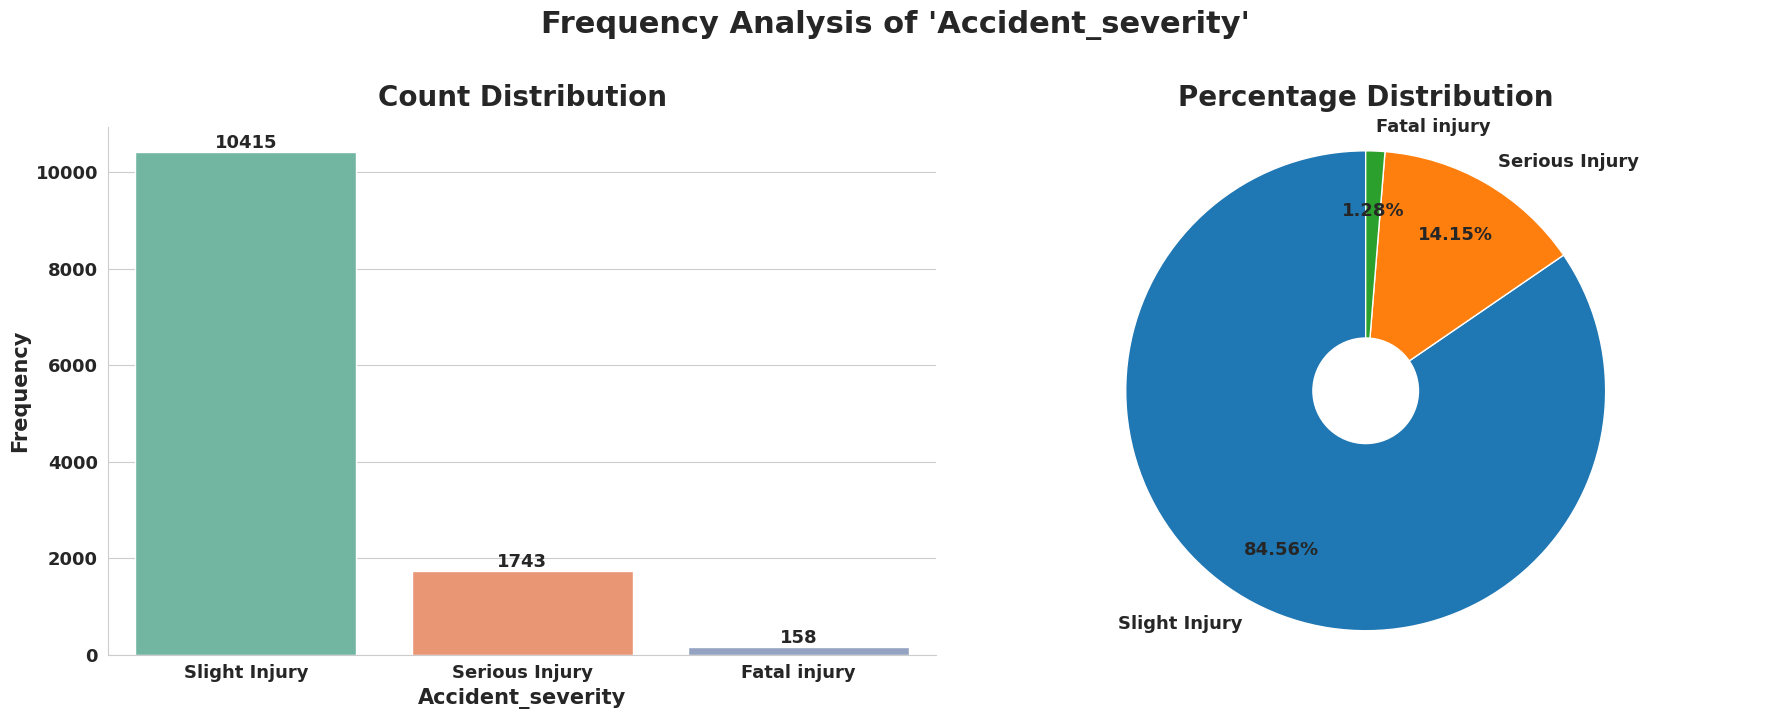

In [19]:
plot_count_and_donut(raw_df, 'Accident_severity')

### 5.3 Research Question: Accidents by Day and Gender

Research Question : How many accidents per Day and per Gender ?

In [20]:

accidents_per_day = raw_df['Day_of_week'].value_counts().sort_index()
print("Number of Accidents Per Day")
print(accidents_per_day)


Number of Accidents Per Day
Day_of_week
Friday       2041
Monday       1681
Saturday     1666
Sunday       1467
Thursday     1851
Tuesday      1770
Wednesday    1840
Name: count, dtype: int64


In [21]:
accidents_per_gender = raw_df['Sex_of_driver'].value_counts().sort_index()
print("Number of Accidents Per Gender")
print(accidents_per_gender)

Number of Accidents Per Gender
Sex_of_driver
Female       701
Male       11437
Unknown      178
Name: count, dtype: int64


### 5.4 Descriptive Statistics

In [22]:
def Descriptive_Statistics(df,dtypes):
  """
  This Method Returns Descriptive Statistics

  """
  print('Descriptive Statistics')
  colums=[]
  for col in df.columns:
    if df[col].dtype in dtypes:
      colums.append(col)
  return (df[colums].describe())




### 5.4.1 Numerical Feature Statistics

In [23]:
Descriptive_Statistics(raw_df,dtypes=['int','float'])

Descriptive Statistics


,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


### 5.4.2 Categorical Feature Statistics

In [24]:
Descriptive_Statistics(raw_df,dtypes=['object','bool'])

Descriptive Statistics


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
count,12316,12316,12316,12316,11575,11737,11487,11366,11834,8388,...,12008,12316,12316,12316,12316,9118,9681,12316,12316,12316
unique,1074,7,5,3,7,4,7,17,4,6,...,13,4,3,6,4,7,5,9,20,3
top,15:30:00,Friday,18-30,Male,Junior high school,Employee,5-10yr,Automobile,Owner,Unknown,...,Going straight,Driver or rider,Male,na,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
freq,120,2041,4271,11437,7619,9627,3363,3205,10459,2883,...,8158,4944,5253,4443,7076,5903,9608,11390,2263,10415


### 5.5 Identifying Categorical Features

In [25]:
# Separate categorical Features
def separate_categorical_features(df):
  """
  This Method Returns Categorical Features
  """
  categorical_features = []
  for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'bool':
      categorical_features.append(col)
  return categorical_features

categorical_features= separate_categorical_features(raw_df)
print("Categorical Features are: ",categorical_features)
print("Total Number of Categorical Features are ",len(categorical_features))

Categorical Features are:  ['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']
Total Number of Categorical Features are  30


## 6. Feature Relationship Analysis

## 6.1 Feature vs Target Analysis

Exploratory Analysis of Variables Affecting Road Accidents


In [26]:
def plot_feature_vs_target_distribution(data, categorical_features, target_col='Accident_severity'):
    """
    Generates catplots to compare frequency distributions of categorical features
    against a target variable.

    Args:
        data (pd.DataFrame): The input DataFrame.
        categorical_features (list): A list of categorical feature names.
        target_col (str): The name of the target column.
    """
    features_to_plot = [f for f in categorical_features if f not in [target_col, 'Time']]

    # Features that might have fewer unique values, suitable for horizontal labels
    features_horiz = ['Sex_of_driver', 'Vehicle_driver_relation', 'Defect_of_vehicle',
                      'Number_of_vehicles_involved', 'Number_of_casualties',
                      'Sex_of_casualty', 'Casualty_severity'] # Note: Number_of_vehicles_involved & Number_of_casualties are numerical here, but included for illustration if they were treated as categories

    print(f"Generating distribution plots for {len(features_to_plot)} categorical features against '{target_col}'...")

    for feature in features_to_plot:
        plt.figure(figsize=(15, 6))

        # Filter out rows where the feature is NaN before plotting
        temp_df = data.dropna(subset=[feature])

        catplot = sns.catplot(data=temp_df,
                              x=feature,
                              col=target_col,
                              kind='count',
                              sharey=False,
                              palette='viridis')

        # Adjust titles and labels
        catplot.set_axis_labels(feature, 'Frequency', fontsize=12, fontweight='bold')
        catplot.set_titles("Accident Severity: {col_name}")

        # Rotate x-tick labels if the feature is not in features_horiz
        if feature not in features_horiz:
            catplot.set_xticklabels(rotation=90, ha='right', fontsize=10, fontweight='bold')
        else:
            catplot.set_xticklabels(fontsize=10, fontweight='bold')

        plt.suptitle(f"Frequency distribution of '{feature}' by '{target_col}'", y=1.02, fontsize=15, fontweight='bold')
        plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
        plt.show()




Generating distribution plots for 28 categorical features against 'Accident_severity'...


<Figure size 1500x600 with 0 Axes>

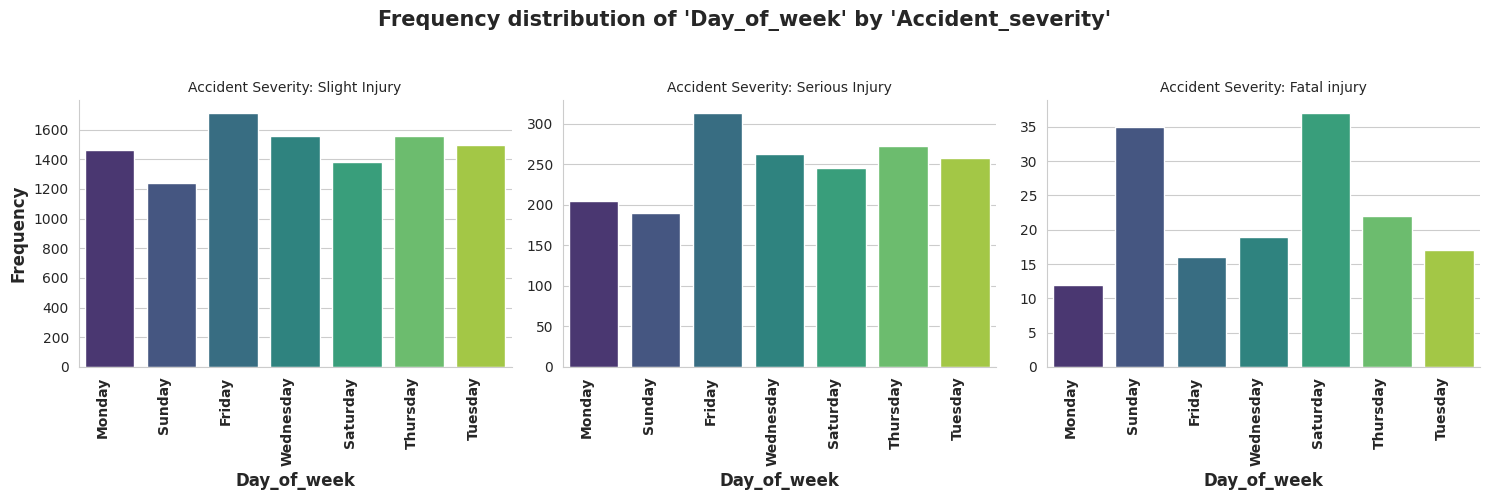

<Figure size 1500x600 with 0 Axes>

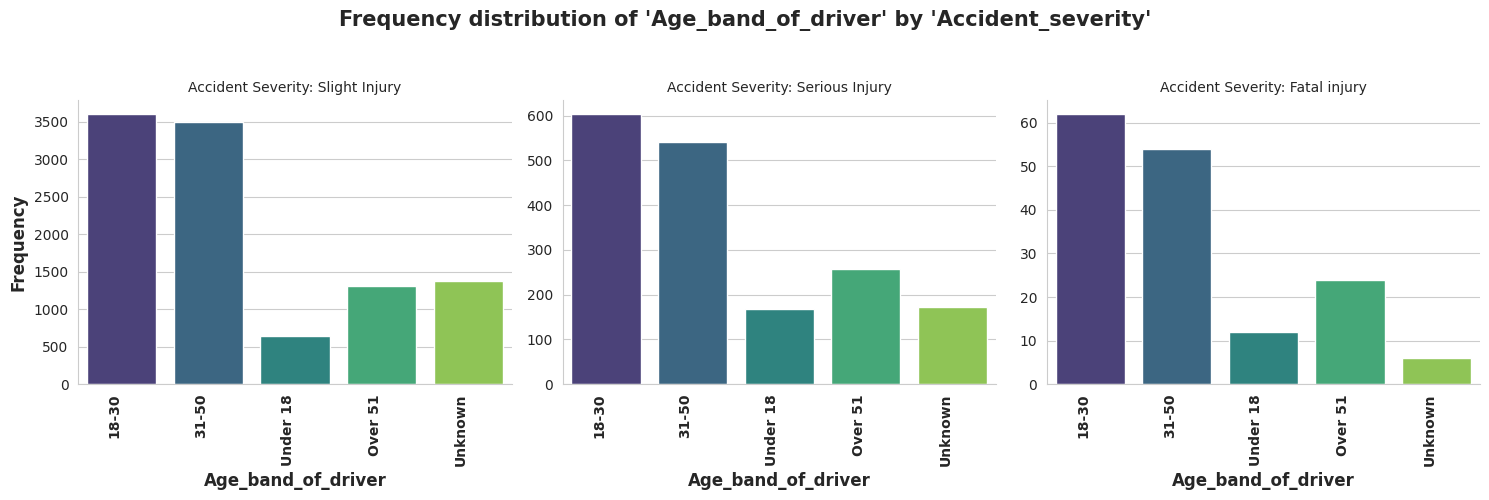

<Figure size 1500x600 with 0 Axes>

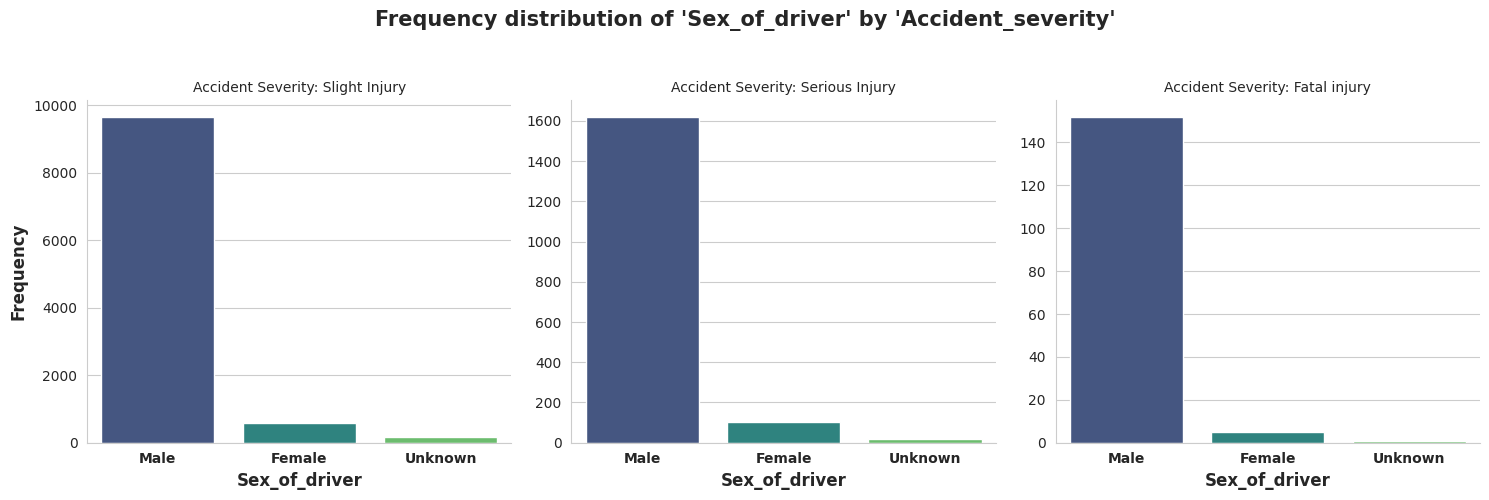

<Figure size 1500x600 with 0 Axes>

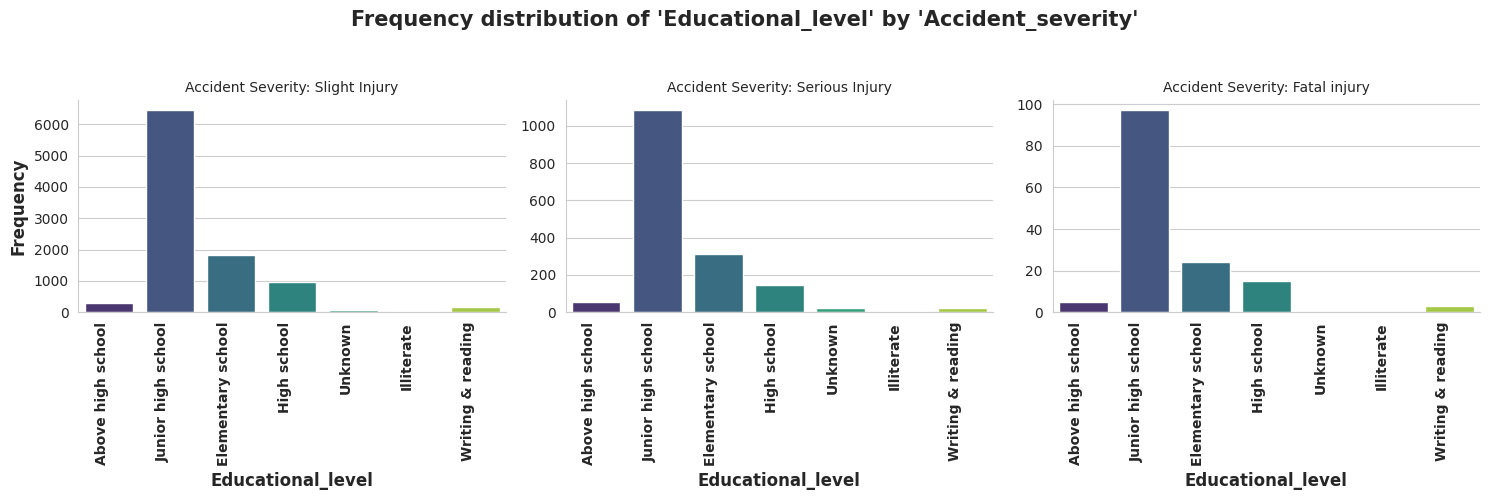

<Figure size 1500x600 with 0 Axes>

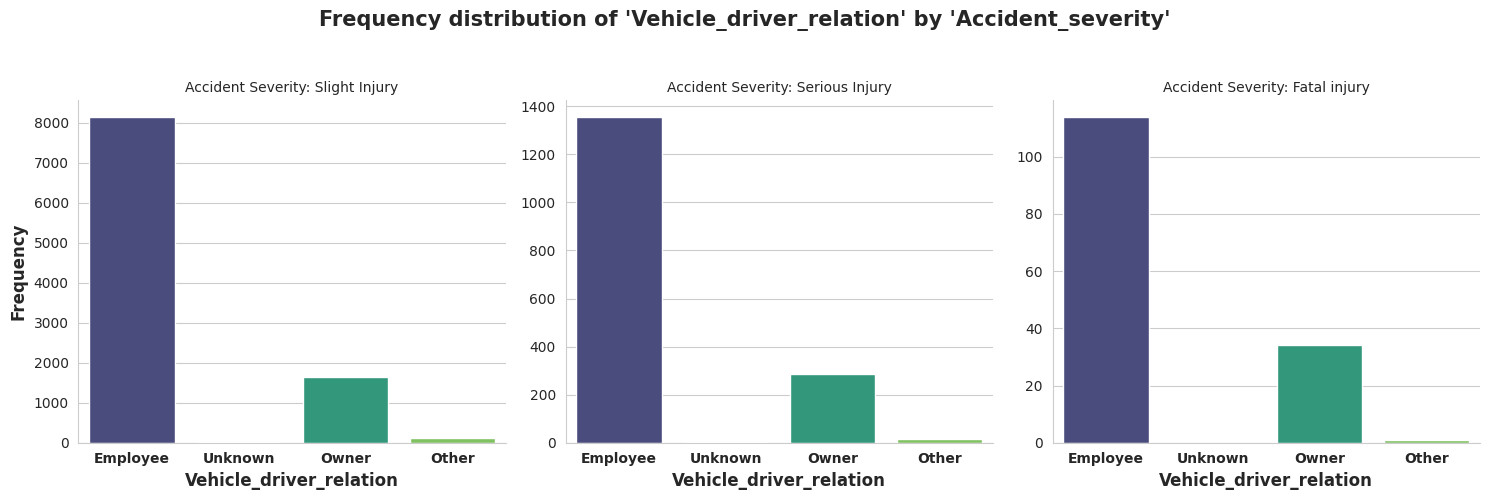

<Figure size 1500x600 with 0 Axes>

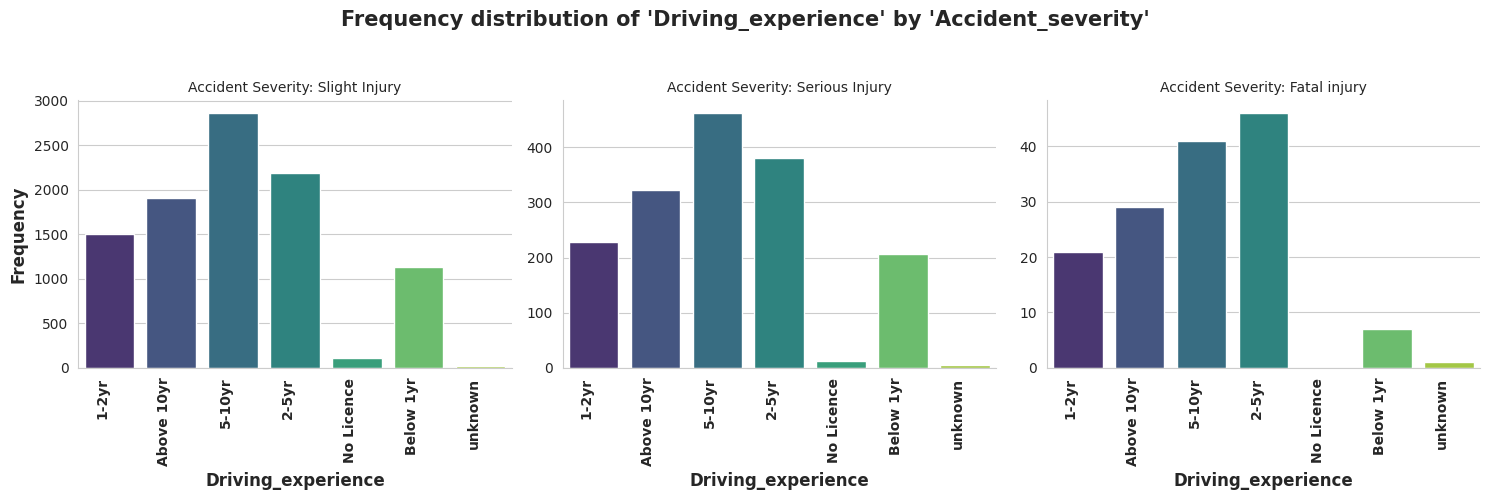

<Figure size 1500x600 with 0 Axes>

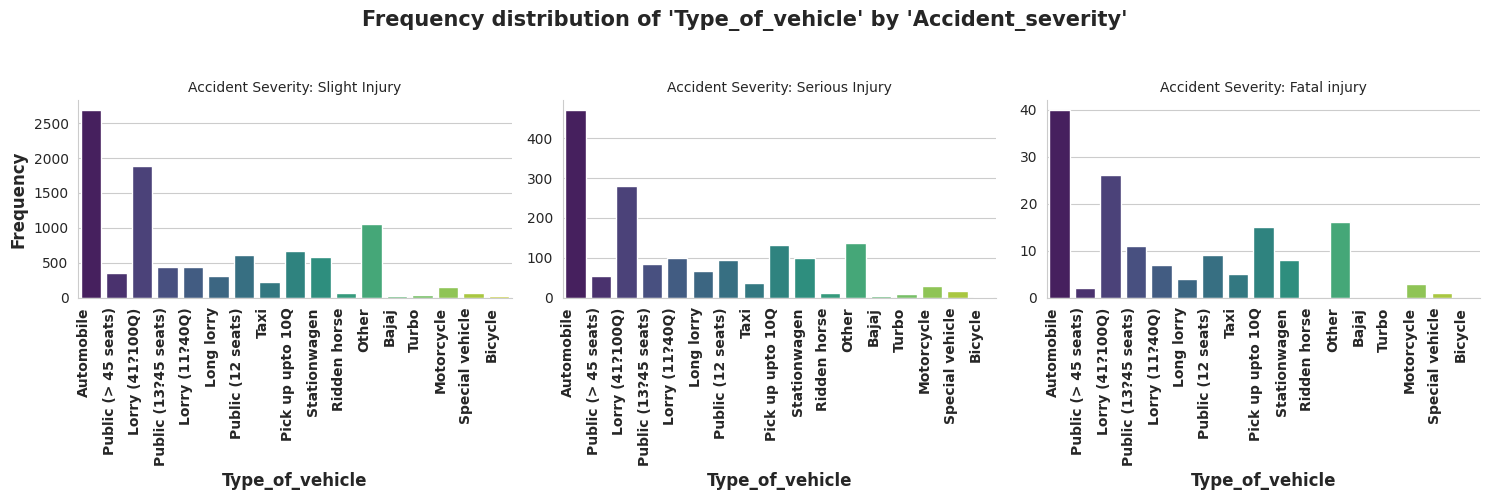

<Figure size 1500x600 with 0 Axes>

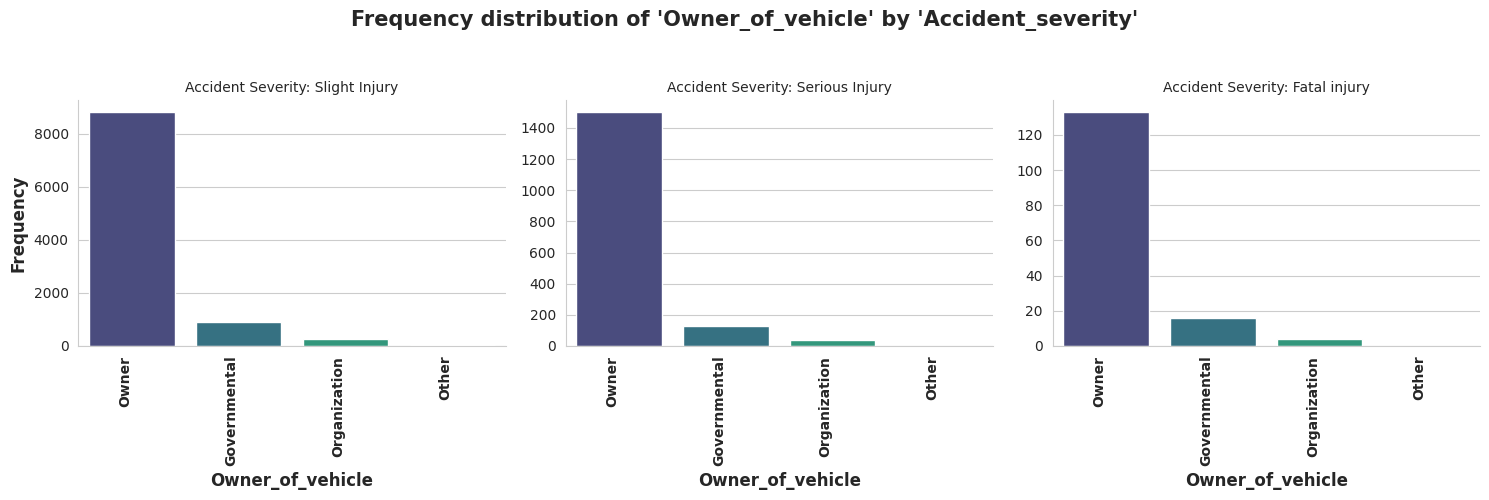

<Figure size 1500x600 with 0 Axes>

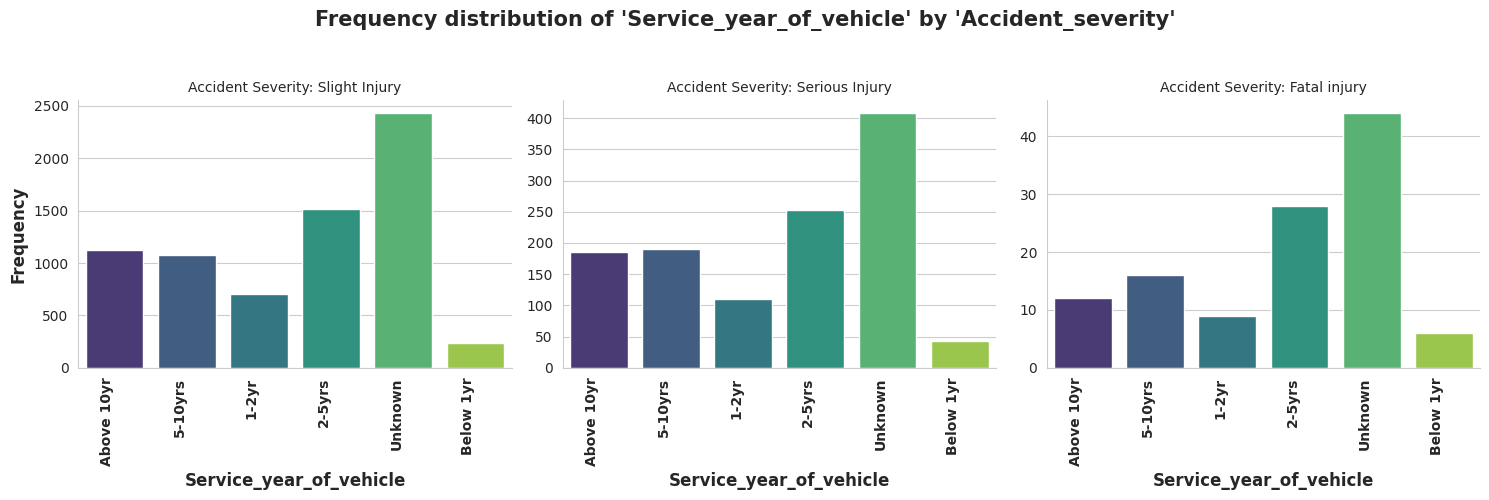

<Figure size 1500x600 with 0 Axes>

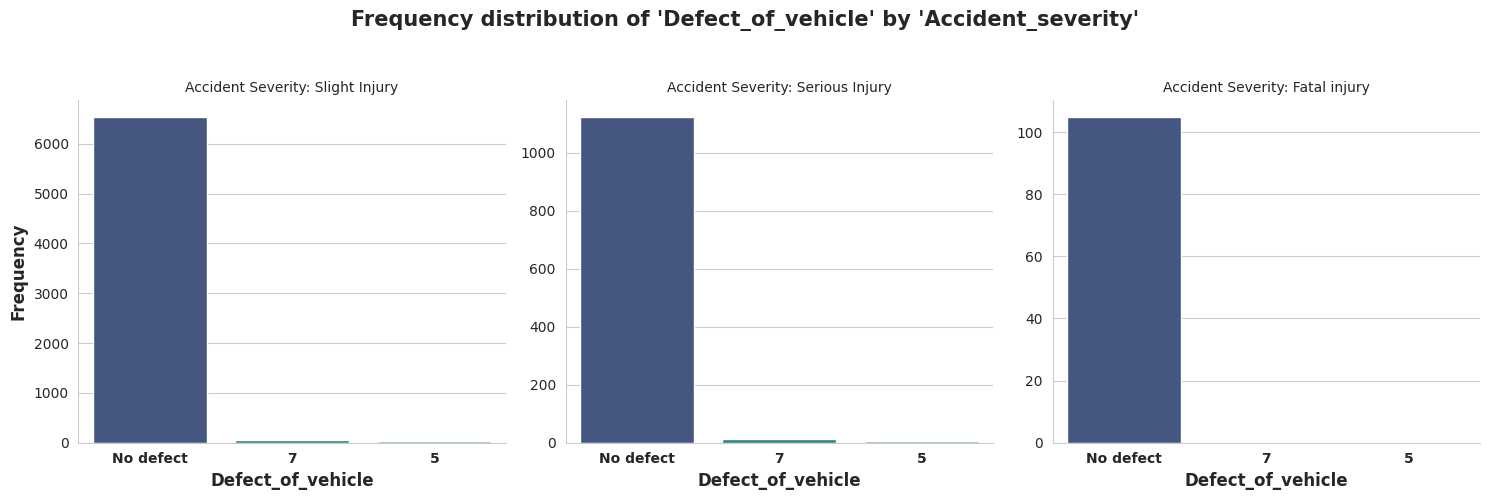

<Figure size 1500x600 with 0 Axes>

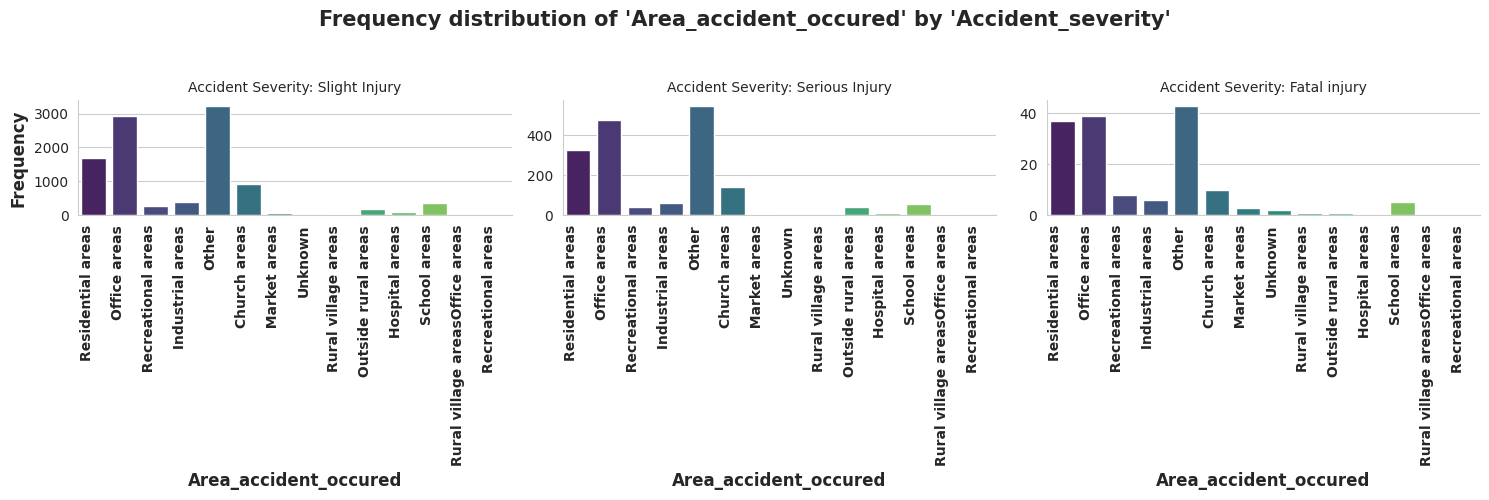

<Figure size 1500x600 with 0 Axes>

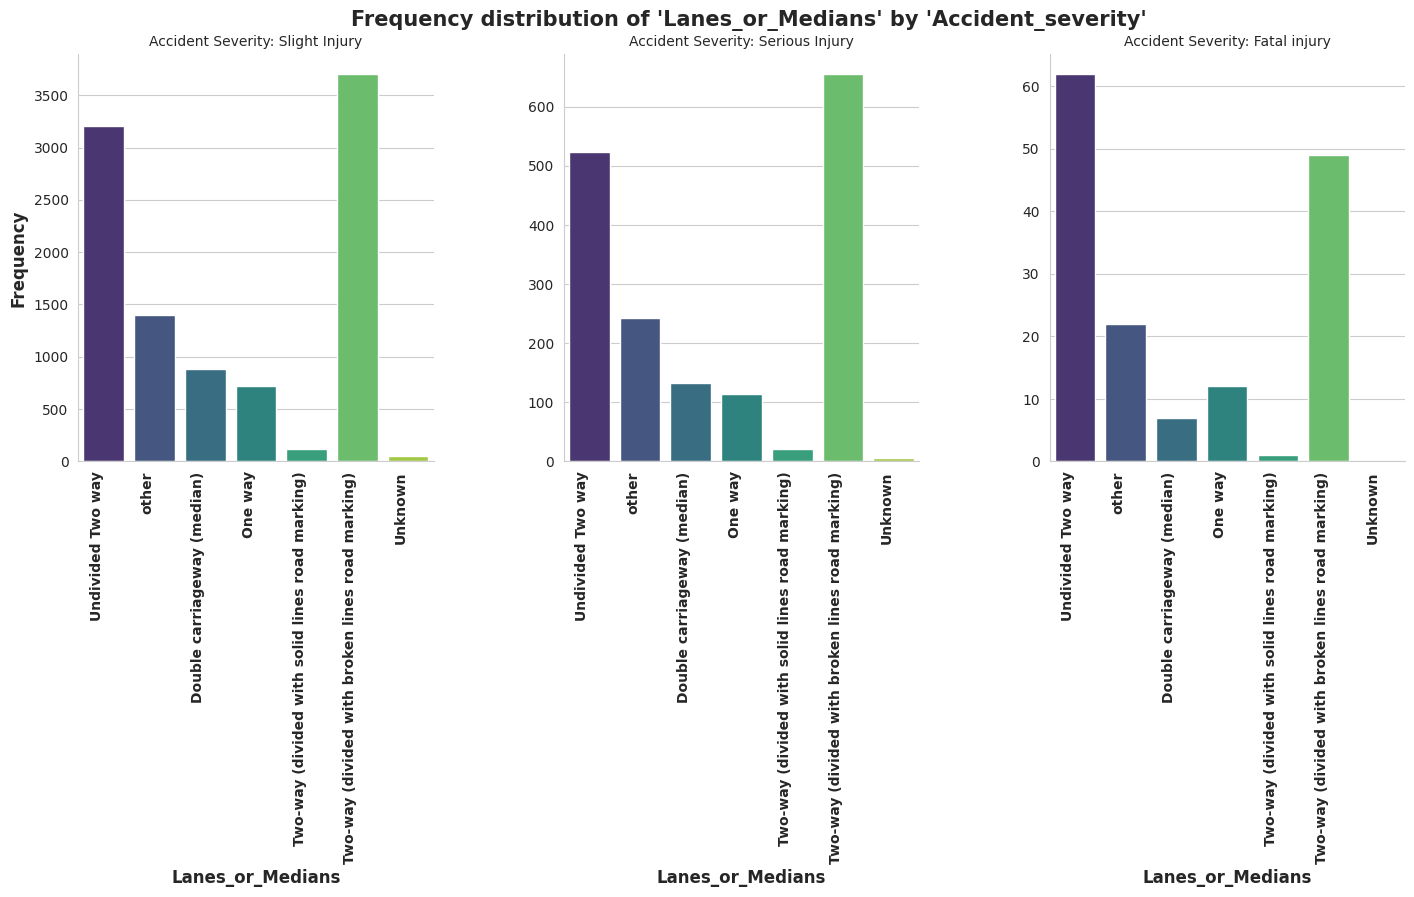

<Figure size 1500x600 with 0 Axes>

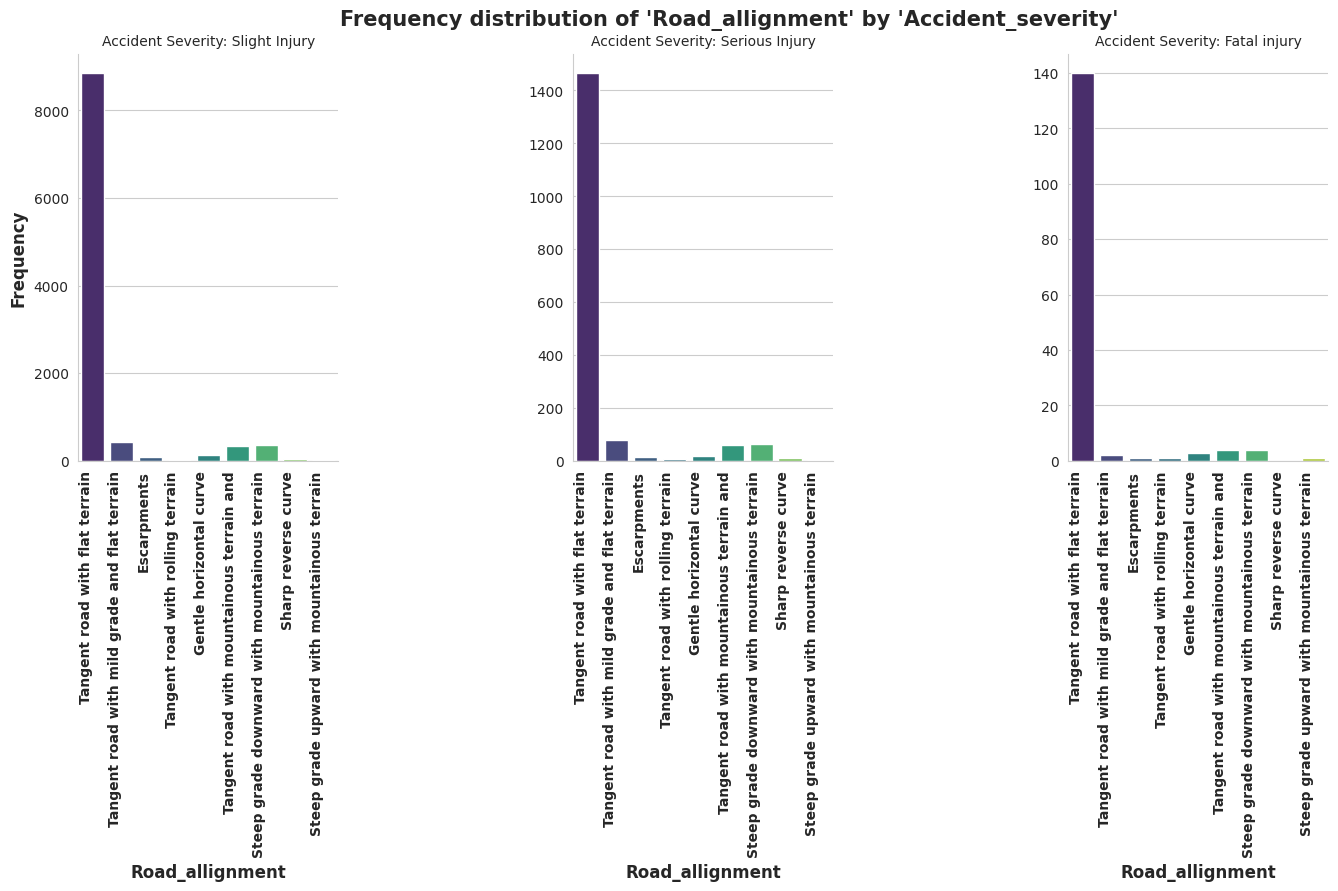

<Figure size 1500x600 with 0 Axes>

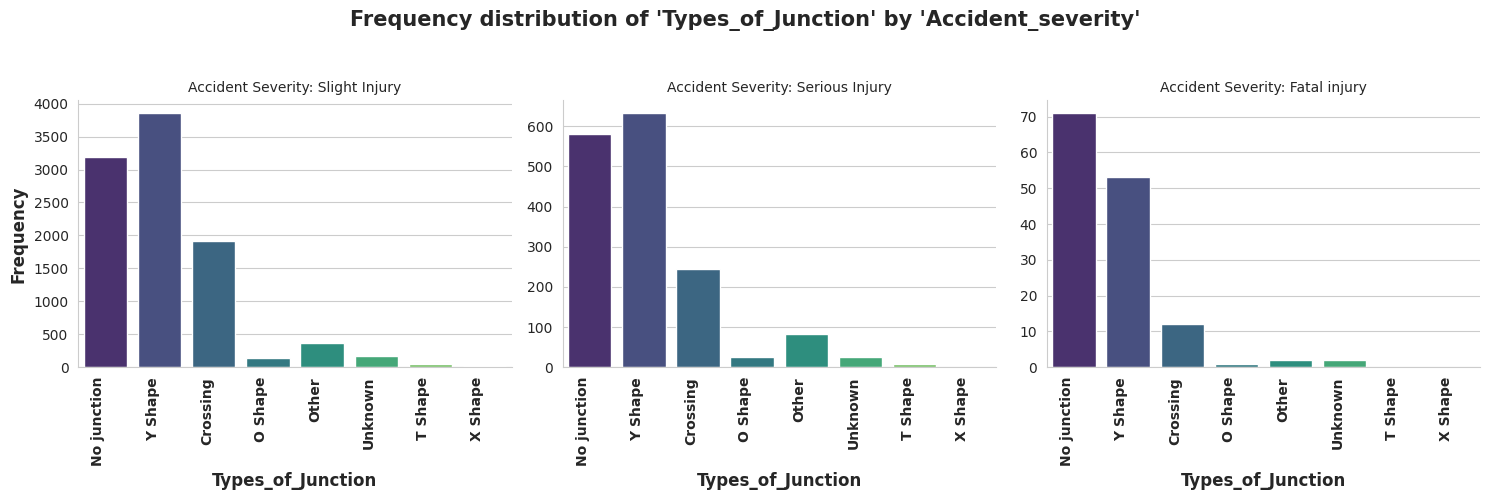

<Figure size 1500x600 with 0 Axes>

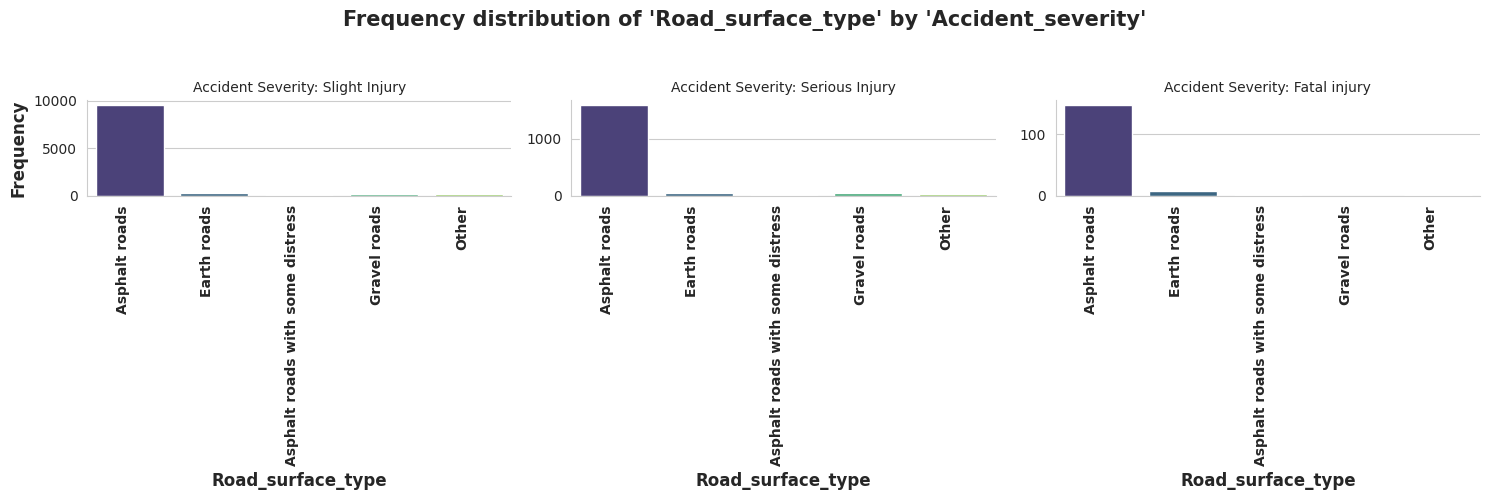

<Figure size 1500x600 with 0 Axes>

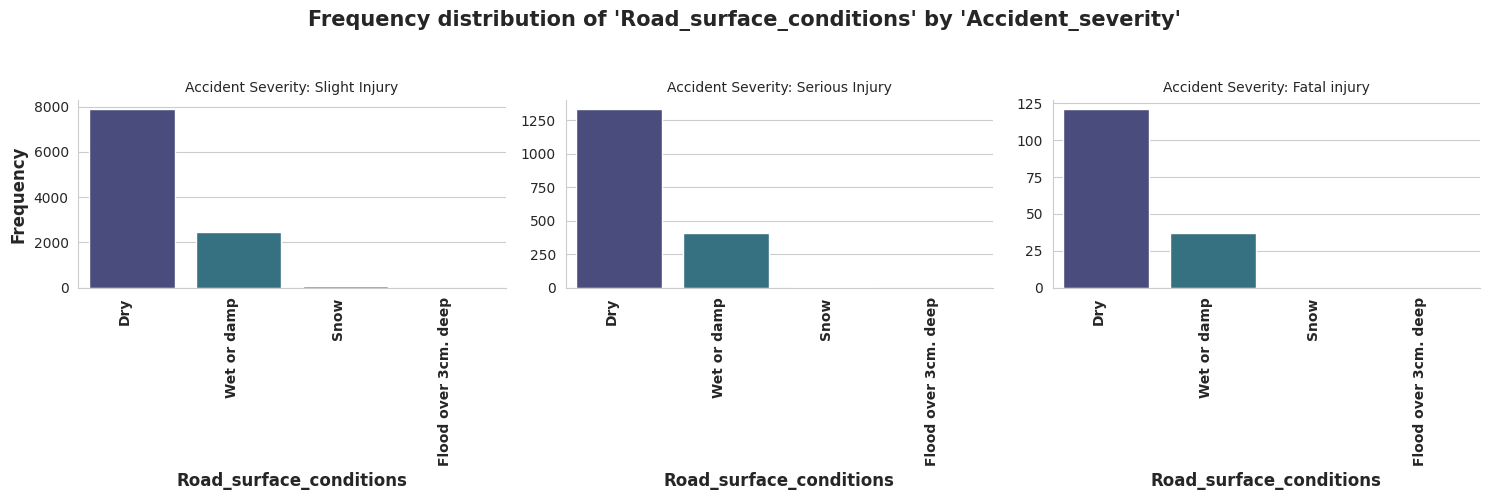

<Figure size 1500x600 with 0 Axes>

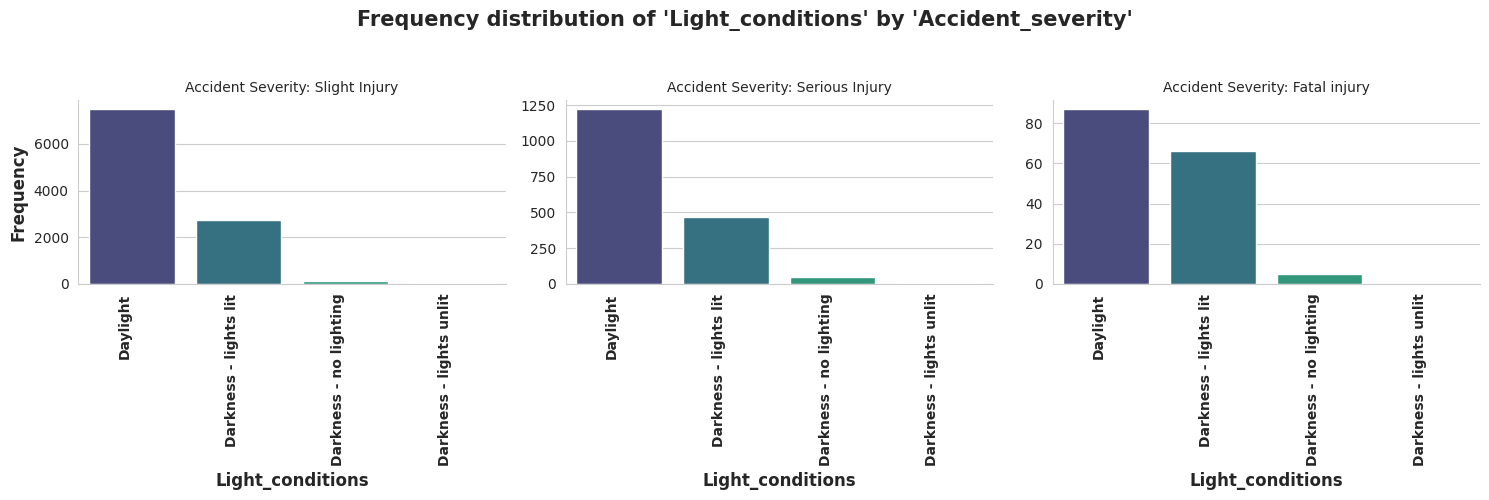

<Figure size 1500x600 with 0 Axes>

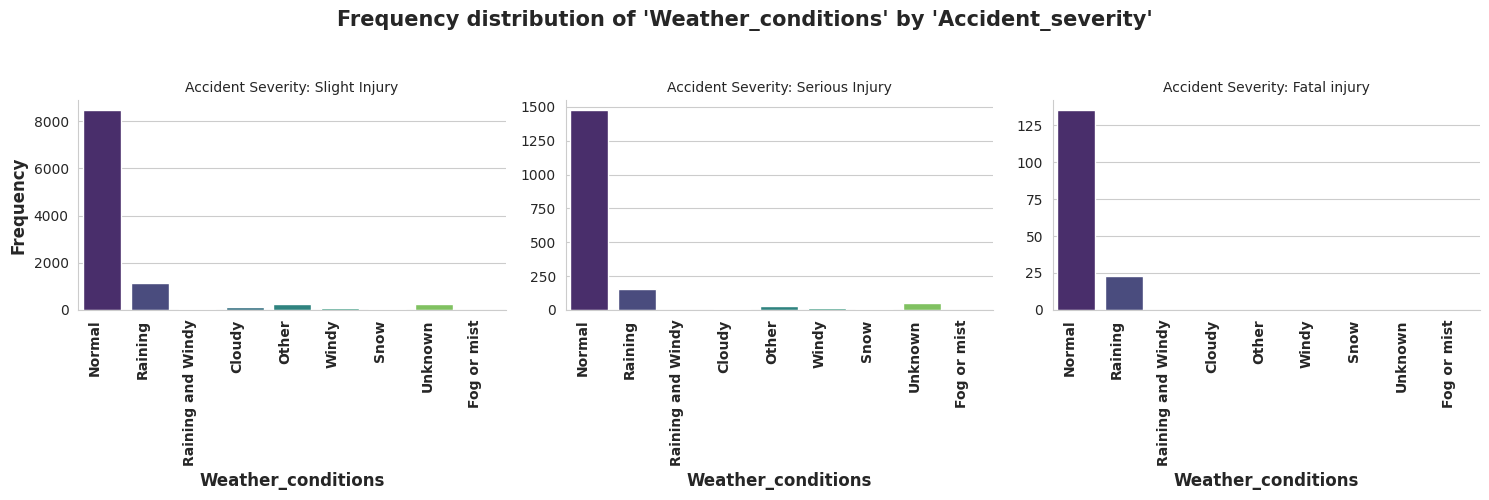

<Figure size 1500x600 with 0 Axes>

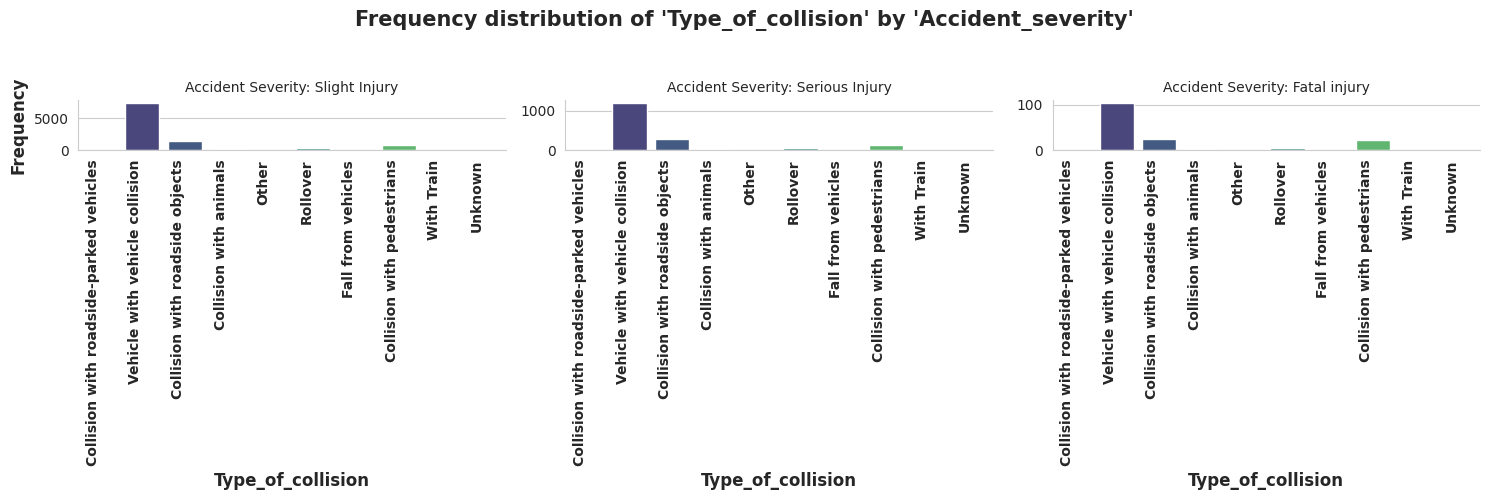

<Figure size 1500x600 with 0 Axes>

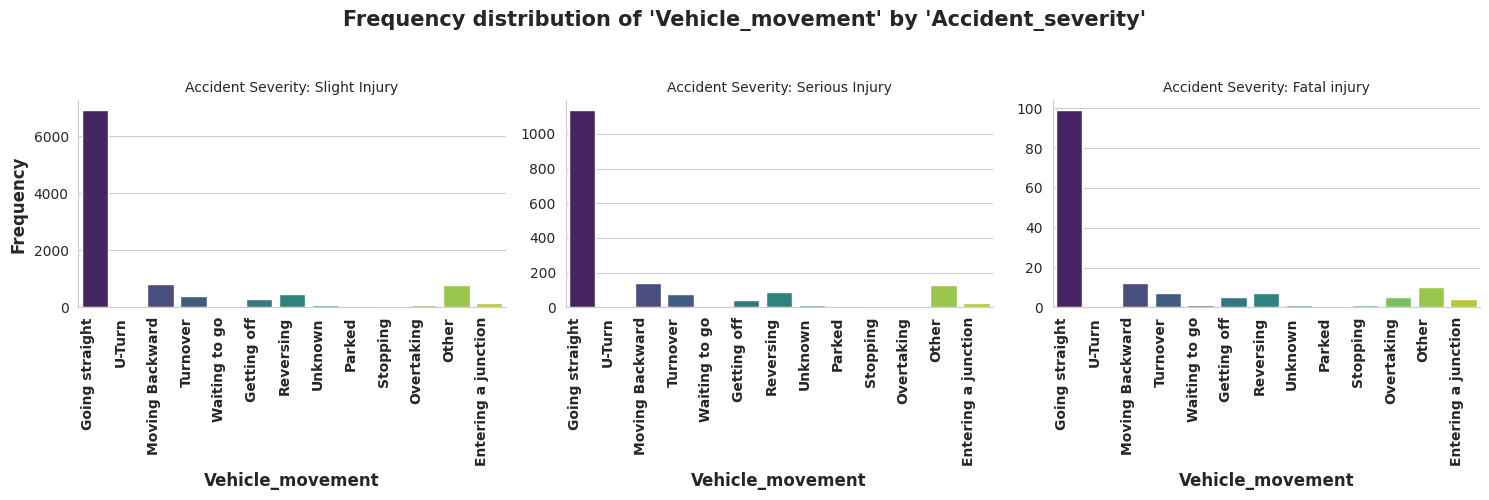

<Figure size 1500x600 with 0 Axes>

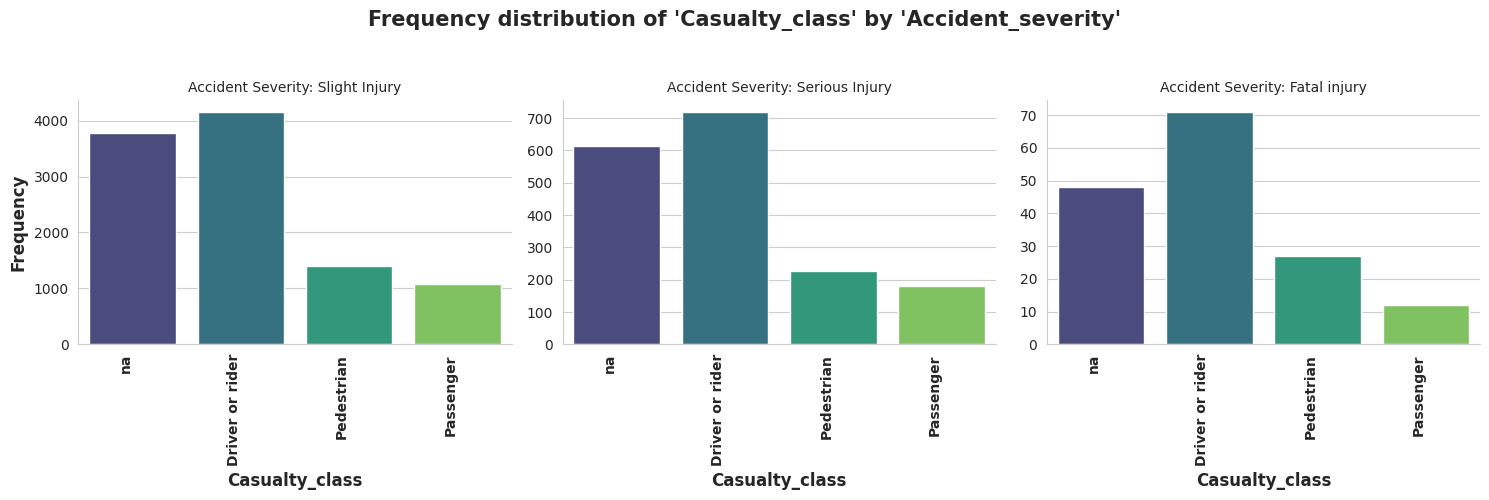

<Figure size 1500x600 with 0 Axes>

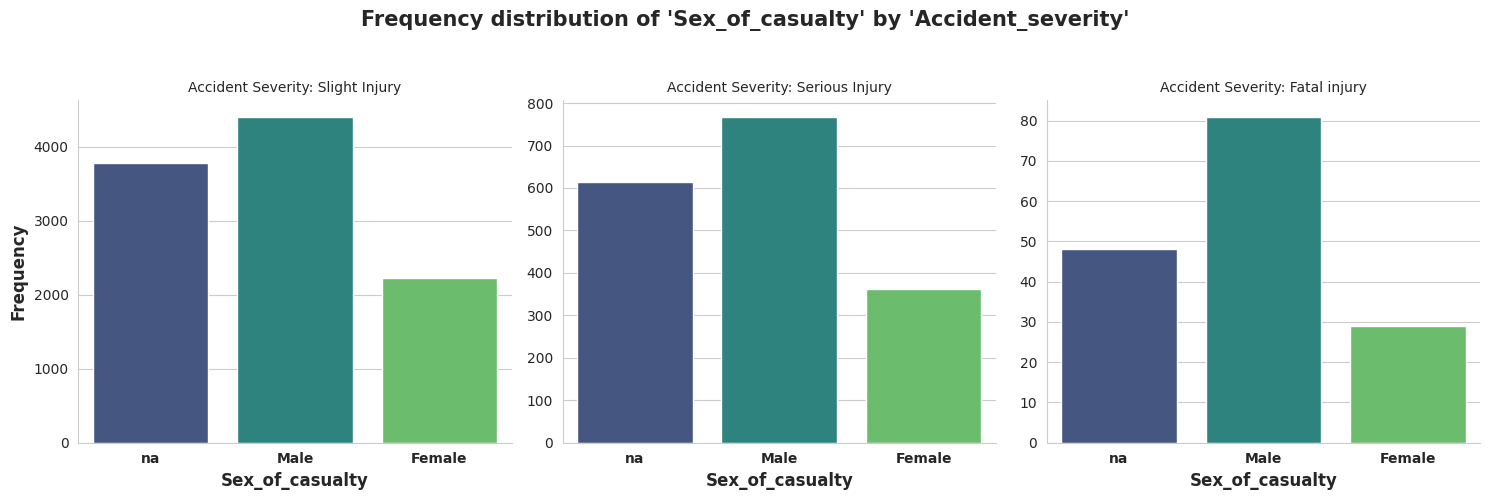

<Figure size 1500x600 with 0 Axes>

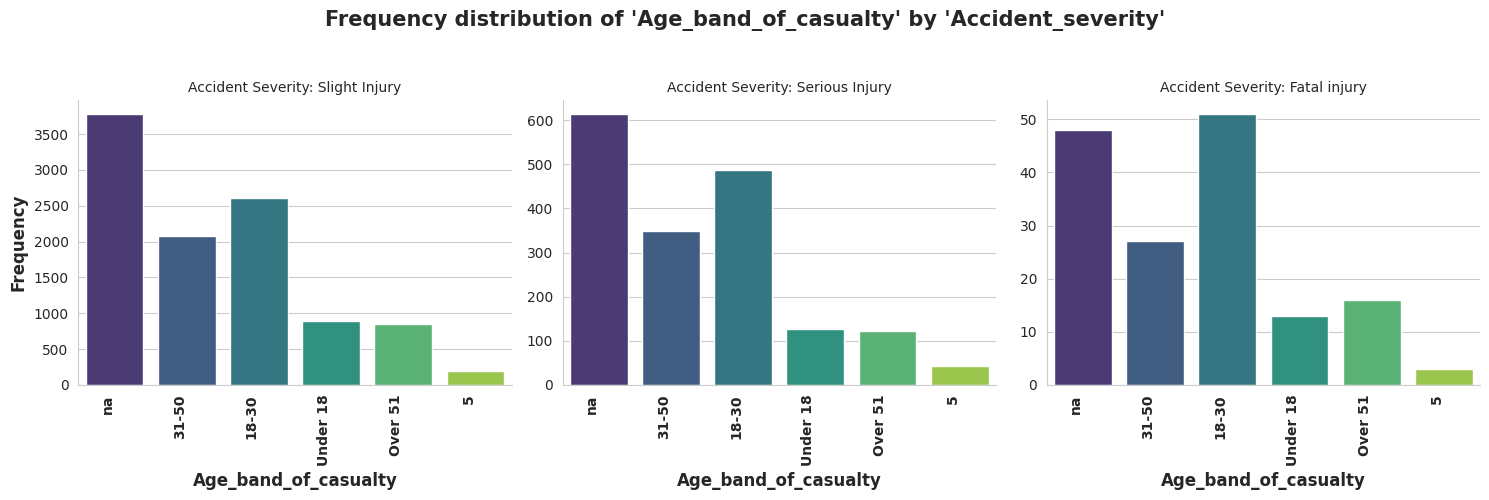

<Figure size 1500x600 with 0 Axes>

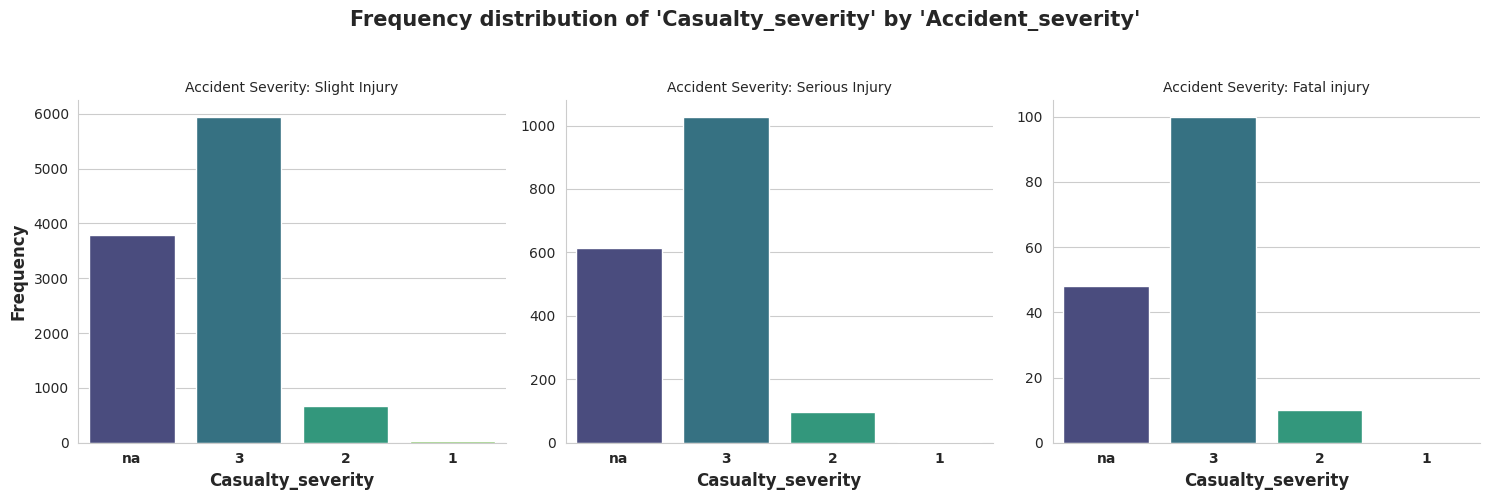

<Figure size 1500x600 with 0 Axes>

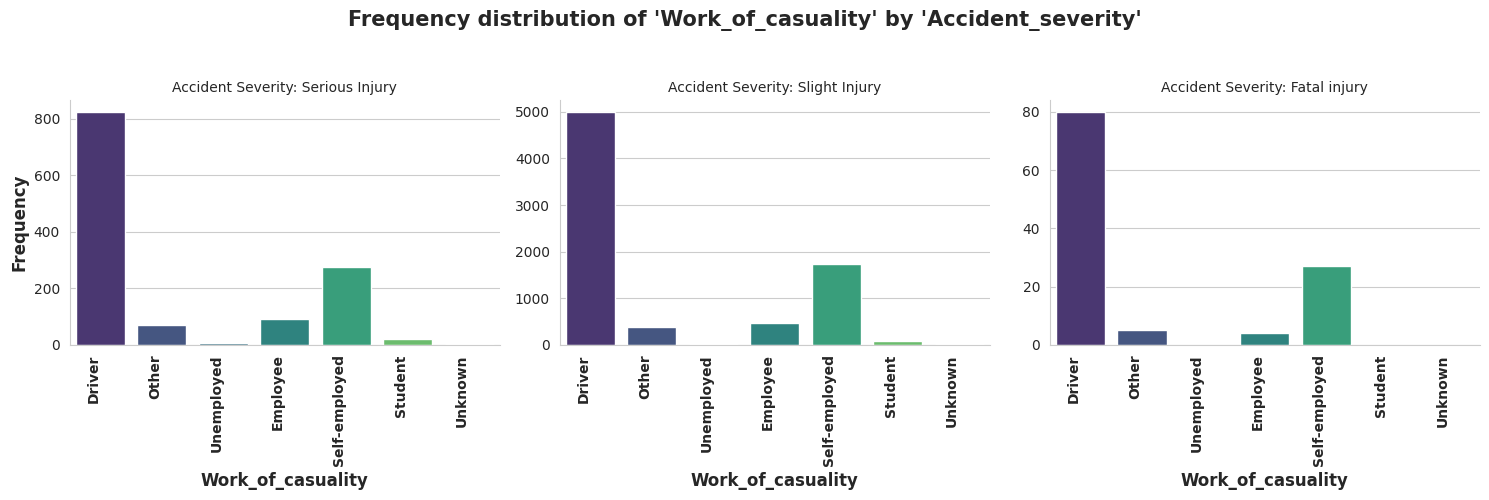

<Figure size 1500x600 with 0 Axes>

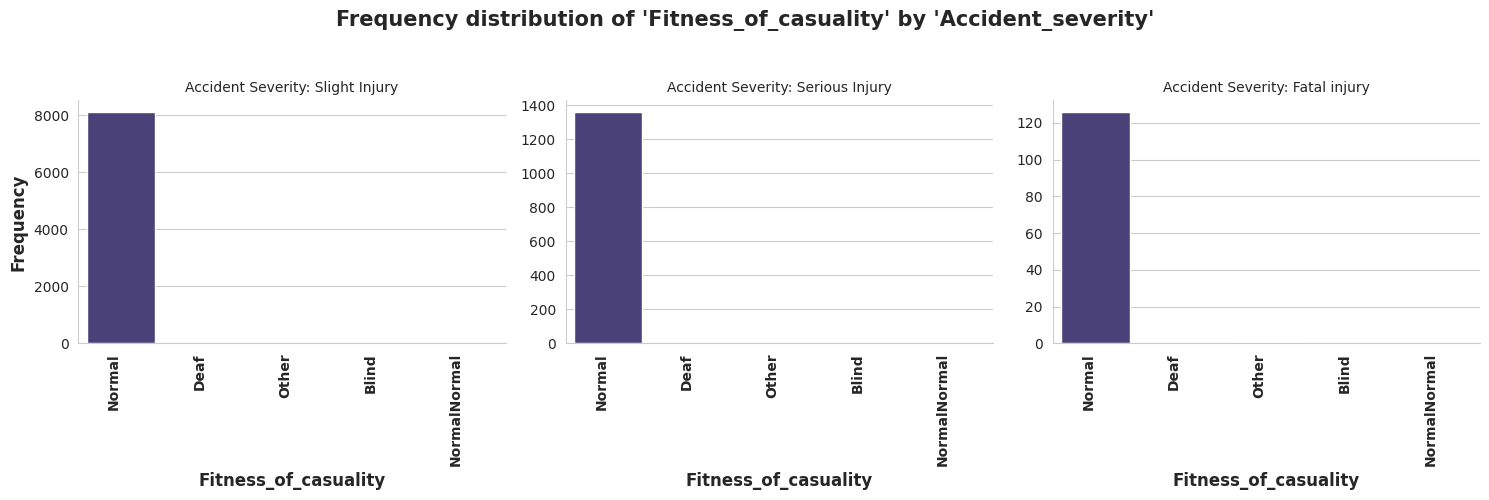

<Figure size 1500x600 with 0 Axes>

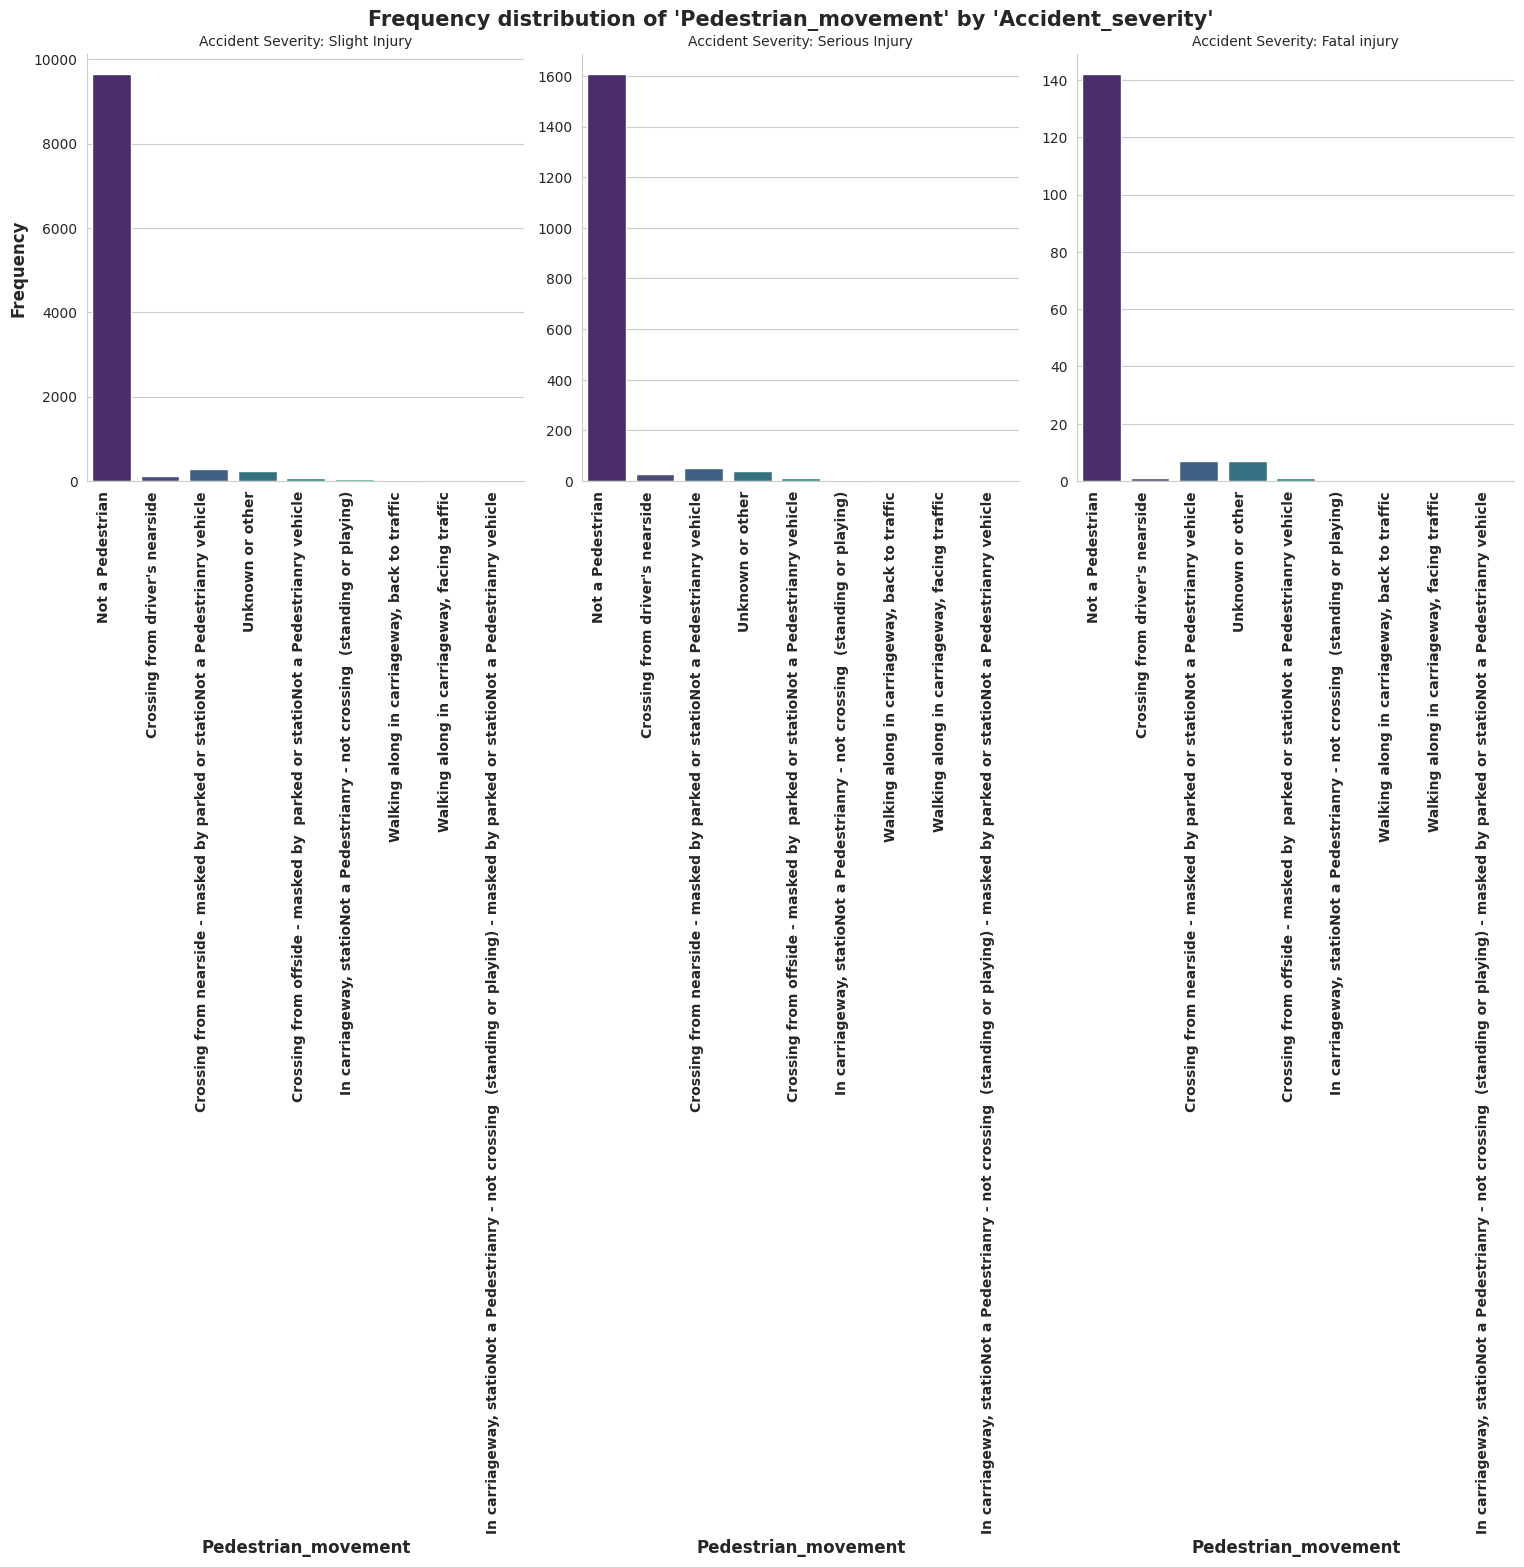

<Figure size 1500x600 with 0 Axes>

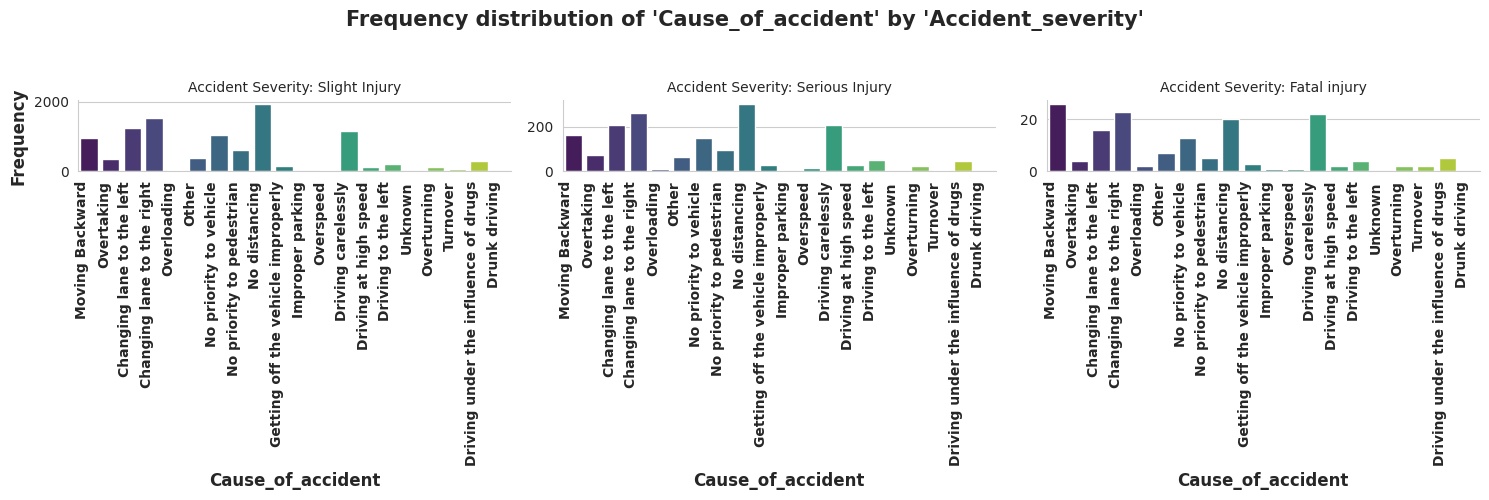

In [27]:
plot_feature_vs_target_distribution(raw_df, categorical_features, 'Accident_severity')

## 7. Outlier Detection in Numerical Features|

## Research Question  
- Are there any significant outliers present in the numeric variables?

In [28]:

def outliers_detection(df, numerical_features, target):
    """
    Generate boxplots for outlier detection
    for each numerical feature against target.
    """

    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found in DataFrame.")

    n_features = len(numerical_features)
    cols = 2
    rows = math.ceil(n_features / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

    # Flatten axes for easy iteration
    axes = axes.flatten() if n_features > 1 else [axes]

    for i, feature in enumerate(numerical_features):

        if feature not in df.columns:
            raise ValueError(f"Column '{feature}' not found in DataFrame.")

        ax = axes[i]

        sns.boxplot(
            data=df,
            hue=target,
            x=feature,
            y=target,
            ax=ax
        )

        ax.set_title(f"Boxplot of {feature}",
                     fontsize=14,
                     fontweight='bold')

        ax.set_xlabel(feature,
                      fontsize=12,
                      fontweight='bold')

        ax.set_ylabel(target,
                      fontsize=12,
                      fontweight='bold')

        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        # Bold ticks
        for label in ax.get_xticklabels():
            label.set_fontweight('bold')
        for label in ax.get_yticklabels():
            label.set_fontweight('bold')

    # Remove unused axes if odd number of plots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [32]:
import math
def separate_numerical_features(df):
  """
  This Method Returns Numerical Features
  """
  numerical_features = []
  for col in df.columns:
    if df.dtypes[col] in ['int64', 'float64']:
      numerical_features.append(col)
  return numerical_features

In [33]:
numerical_features=separate_numerical_features(raw_df)

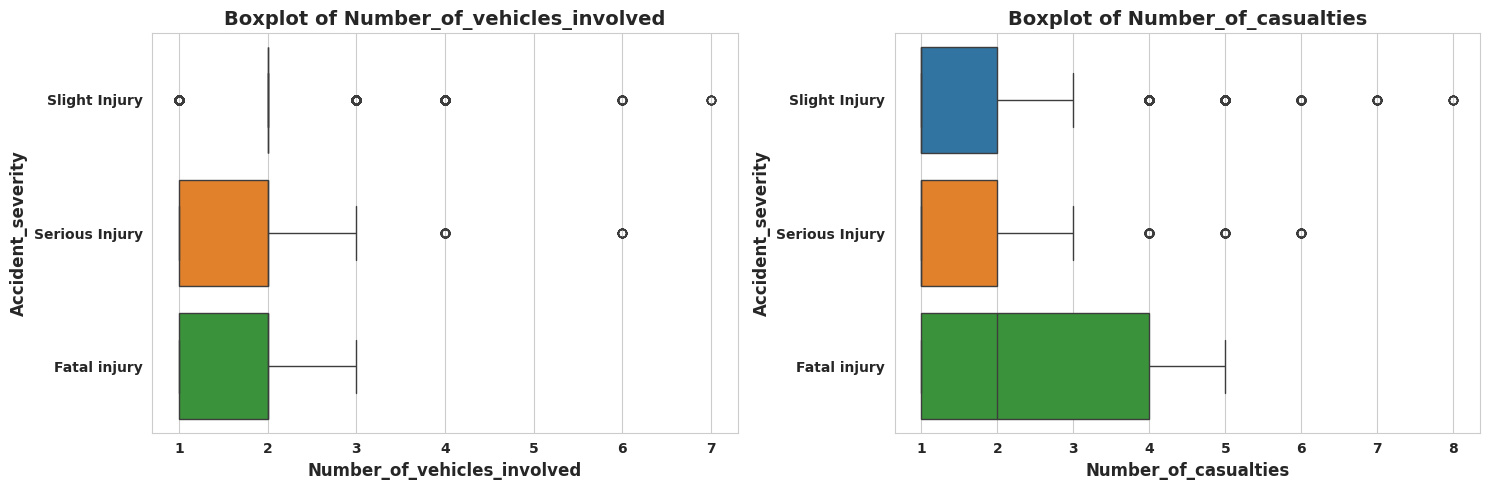

In [34]:
outliers_detection(raw_df,numerical_features,'Accident_severity')

### 8. Time Feature Transformation and Distribution Analysis

The **Time** feature is originally recorded in **HH:MM:SS format**, so it is converted into **seconds since midnight** to allow numerical analysis. Under this mapping, time ranges from **0 seconds (12 a.m.) to 86,400 seconds (24 hours)**.

For example:
- **00:00:00 → 0 seconds (12 a.m.)**
- **06:00:00 → 21,600 seconds (6 a.m.)**
- **12:00:00 → 43,200 seconds (12 p.m.)**
- **18:00:00 → 64,800 seconds (6 p.m.)**
- **24:00:00 → 86,400 seconds (next day 12 a.m.)**

In the histogram, each bin represents a **one-hour interval**, and the x-axis labels are converted back to **a.m./p.m. format** for easier interpretation of accident distribution throughout the day.

In [35]:
# Convertion of time from hh:mm:ss format to seconds
def convert_to_seconds(x):
    h = int(x.split(':')[0])
    m = int(x.split(':')[1])
    s = int(x.split(':')[2])
    return (h*60*60)+(m*60)+s

raw_df['Time'] = raw_df['Time'].apply(convert_to_seconds)

In [36]:
def plot_time_distribution_by_severity(data):
    """
    Plot time distribution of accidents for each severity category
    with bold titles, labels, and tick values.
    """

    data_slight = data[data['Accident_severity'] == 'Slight Injury']
    data_serious = data[data['Accident_severity'] == 'Serious Injury']
    data_fatal = data[data['Accident_severity'] == 'Fatal injury']

    datasets = [
        (data_slight, "Accidents with Slight Injury"),
        (data_serious, "Accidents with Serious Injury"),
        (data_fatal, "Accidents with Fatal Injury")
    ]

    for df, title in datasets:

        plt.figure(figsize=(15,6))

        nbin = int(np.sqrt(len(df)))

        ax = sns.histplot(
            df,
            x='Time',
            color='#5975a4',
            kde=True,
            bins=nbin
        )

        # Title
        ax.set_title(title, fontsize=16, fontweight='bold')

        # X label
        ax.set_xlabel("Time of Day", fontsize=13, fontweight='bold')

        # Y label
        ax.set_ylabel("Frequency", fontsize=13, fontweight='bold')

        # X limits
        ax.set_xlim(-4000, 90400)

        # X ticks
        ax.set_xticks(np.arange(0, 86500, 21600))
        ax.set_xticklabels(
            ['12 a.m.', '6 a.m.', '12 p.m.', '6 p.m.', '12 a.m.'],
            fontweight='bold'
        )

        # Make Y ticks bold
        for label in ax.get_yticklabels():
            label.set_fontweight('bold')

        plt.show()
        print("")

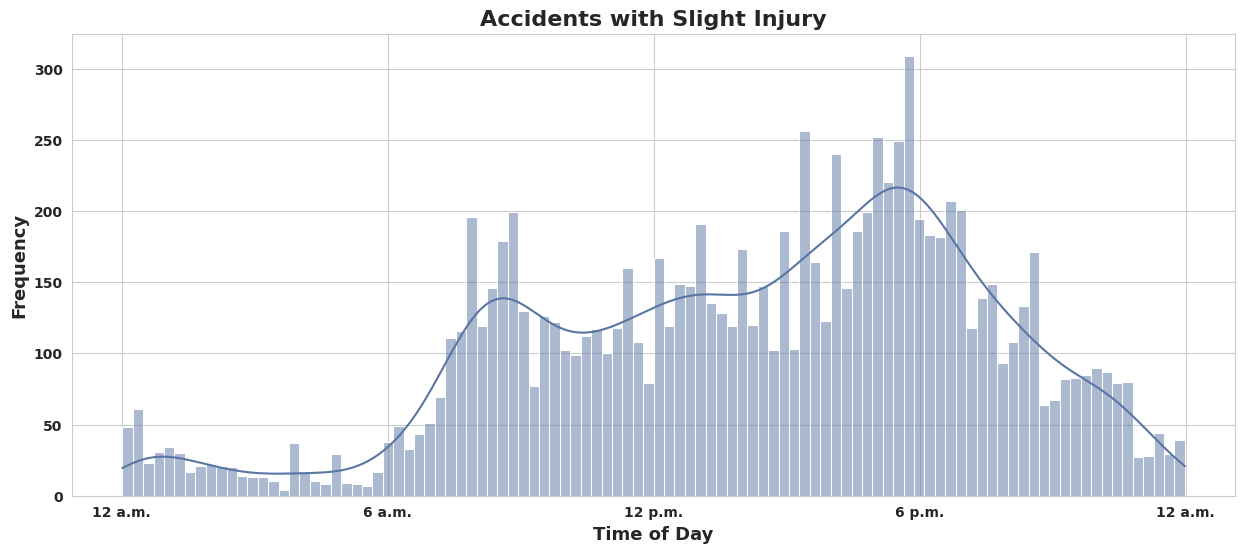

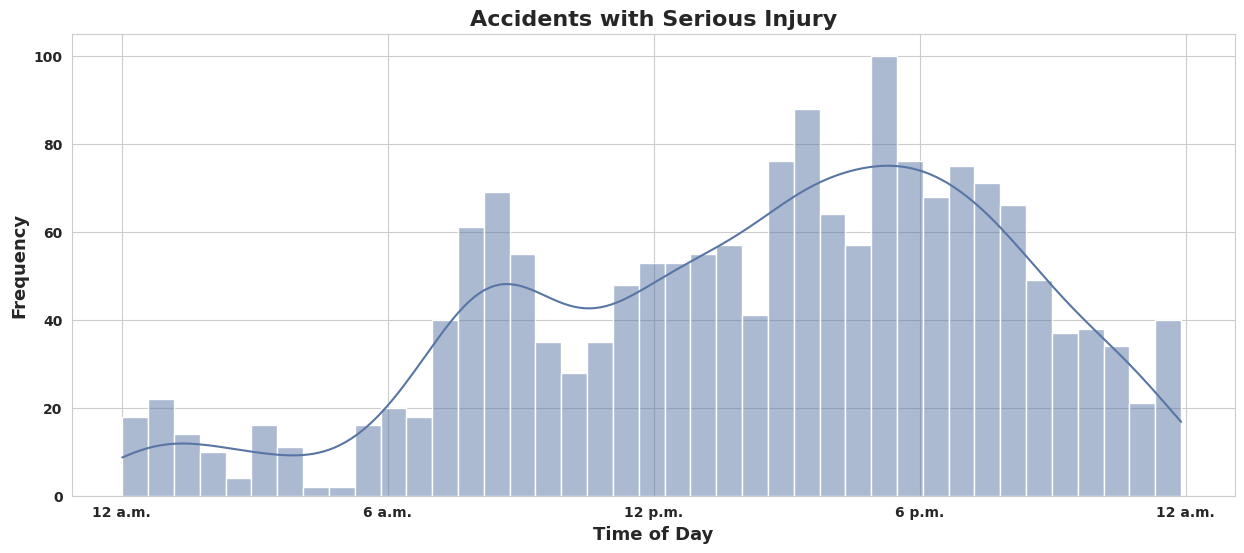

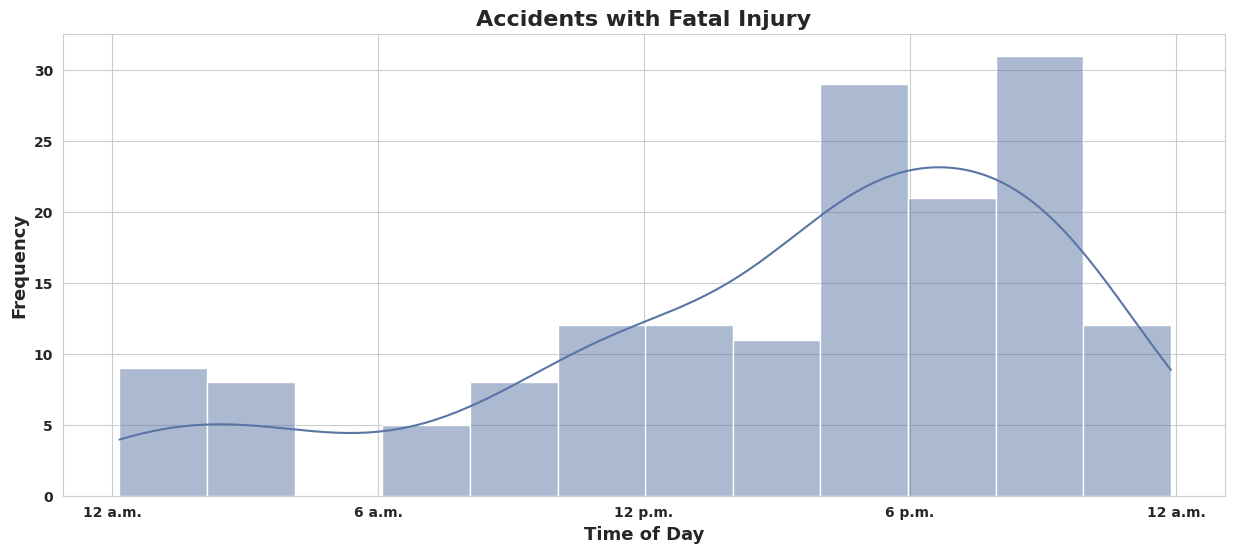

In [37]:
plot_time_distribution_by_severity(raw_df)

## 9. Data Preprocessing

## 9.1. Missing Data Imputation

In [38]:
# Combining similar values
def combine_similar(data):
    data = data.replace('Unknown', 'unknown')
    data = data.replace('Other', 'other')
    data = data.replace('Unknown or other', 'other')
    data = data.replace('Darkness - lights unlit', 'Darkness - no lighting')
    data['Age_band_of_casualty'] = data['Age_band_of_casualty'].replace('5', 'Under 18')
    return data

In [39]:
raw_df = combine_similar(raw_df)

In [40]:
# Columns with missing values (sorted by count)
raw_df.isna().sum()[raw_df.isna().sum() != 0].sort_values(ascending = False)

,0
Defect_of_vehicle,4427
Service_year_of_vehicle,3928
Work_of_casuality,3198
Fitness_of_casuality,2635
Type_of_vehicle,950
Types_of_Junction,887
Driving_experience,829
Educational_level,741
Vehicle_driver_relation,579
Owner_of_vehicle,482


In [41]:
# Rows with missing values (sorted by count)
raw_df.T.isna().sum()[raw_df.T.isna().sum() != 0].sort_values(ascending = False)

,0
2035,11
1022,11
1191,11
5,10
174,10
...,...
7409,1
7402,1
12309,1
12308,1


In [42]:
# Converting unknown/other/na to nan
def more_missing(data):
    data = data.replace('unknown', np.nan)
    data = data.replace('other', np.nan)
    data = data.replace('na', np.nan)
    return data

In [43]:
raw_df = more_missing(raw_df)

## 9.2 Mode imputation

## 9.2.1 Proportion-based imputation

With the goal of keeping the feature distributions same before and after imputation, we impute the missing values in a column in such a way so that the proportions of the existing unique values in the column remain roughly same as those were prior to the imputation.

In [44]:
def proportion_imputer(df):
    df_imputed = df.copy()

    cols_with_nan = df_imputed.columns[df_imputed.isna().any()]

    for col in cols_with_nan:

        value_distribution = df_imputed[col].value_counts(normalize=True)

        values = value_distribution.index
        probabilities = value_distribution.values

        missing_count = df_imputed[col].isna().sum()

        df_imputed.loc[df_imputed[col].isna(), col] = np.random.choice(
            values,
            size=missing_count,
            p=probabilities
        )

    return df_imputed

In [45]:
# Imputation
data_imp = proportion_imputer(raw_df)

In [46]:
# Assigning the imputed data to the original data
data = data_imp
data.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,61320,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,Pedestrian,Male,Under 18,2,Driver,Normal,Not a Pedestrian,Moving Backward,Slight Injury
1,61320,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,Pedestrian,Male,Under 18,3,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury
2,61320,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,2-5yrs,...,Going straight,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the left,Serious Injury
3,3960,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,2-5yrs,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,3960,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Lorry (41?100Q),Owner,5-10yrs,...,Going straight,Passenger,Male,18-30,3,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury


In [47]:
# Checking for missing values
data.isna().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,0
Vehicle_driver_relation,0
Driving_experience,0
Type_of_vehicle,0
Owner_of_vehicle,0
Service_year_of_vehicle,0


##9.3 Labels Encoding

## 9.3.1 Numerical Columns

In [48]:
# Numerical columns
numerical_cols = [
    'Time',
    'Number_of_vehicles_involved',
    'Number_of_casualties'
]

## 9.3.2 Ordinal Columns

In [49]:

# Ordinal categorical columns
ordinal_cols = [
    'Age_band_of_driver',
    'Educational_level',
    'Driving_experience',
    'Service_year_of_vehicle',
    'Light_conditions',
    'Age_band_of_casualty',
    'Casualty_severity',
    'Accident_severity'
]

## 9.3.3 Nominal Colums

In [50]:
# Nominal categorical columns
nominal_cols = [
    col for col in data.columns
    if col not in numerical_cols + ordinal_cols
]

## 9.3.4 Manual Encoding for Ordinal Columns

In [51]:
ordinal_mappings = {

    'Age_band_of_driver': {
        'Under 18':1, '18-30':2, '31-50':3, 'Over 51':4, 'unknown':10
    },

    'Educational_level': {
        'Illiterate':1, 'Writing & reading':2, 'Elementary school':3,
        'Junior high school':4, 'High school':5, 'Above high school':6,
        'unknown':10
    },

    'Driving_experience': {
        'No Licence':0, 'Below 1yr':1, '1-2yr':2,
        '2-5yr':3, '5-10yr':4, 'Above 10yr':5, 'unknown':10
    },

    'Service_year_of_vehicle': {
        'Below 1yr':1, '1-2yr':2, '2-5yrs':3,
        '5-10yrs':4, 'Above 10yr':5, 'unknown':10
    },

    'Light_conditions': {
        'Darkness - no lighting':1,
        'Darkness - lights lit':2,
        'Daylight':3
    },

    'Age_band_of_casualty': {
        'Under 18':1, '18-30':2, '31-50':3,
        'Over 51':4, 'unknown':10
    },

    'Casualty_severity': {
        '1':1, '2':2, '3':3
    }
}


In [52]:
def manual_encode(df, mappings):
    df = df.copy()

    for col, mapping in mappings.items():
        df[col] = df[col].map(mapping)

    return df

In [53]:
data = manual_encode(data, ordinal_mappings)

## 9.3.5 Label Encoding for Nominal Columns

In [54]:


from sklearn.preprocessing import LabelEncoder

def label_encode(df, columns):

    df = df.copy()

    for col in columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

    return df


data = label_encode(data, nominal_cols)


# Preview
data.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,61320,1,2,1,6,0,2,0,2,5,...,2,2,1,1,2,0,2,5,9,Slight Injury
1,61320,1,3,1,4,0,5,10,2,4,...,2,2,1,1,3,0,2,5,15,Slight Injury
2,61320,1,2,1,4,0,2,5,2,3,...,2,0,1,3,3,0,2,5,0,Serious Injury
3,3960,3,2,1,4,0,4,10,0,3,...,2,2,0,2,3,0,2,5,1,Slight Injury
4,3960,3,2,1,4,0,3,5,2,4,...,2,1,1,2,3,0,2,5,15,Slight Injury


## 9.3.6 Normalization
The converted time takes huge values and is likely to distort the training procedure. The next function gives a way to normalize the time variable.

In [55]:
# Function to normalize time variable
def normalize_time(data, c = 1):
    data_normalized = data.copy(deep = True)
    if 'Time' in data_normalized.columns:
        if data_normalized['Time'].max() > c:   # To prevent unnecessary shrinkage
            data_normalized['Time'] = c * data_normalized['Time'] / (24*60*60)
    return data_normalized

In [56]:
data=normalize_time(data)

## 9.3.7 Target Encoding

In [57]:
# Define mapping
severity_map = {
    "Slight Injury": 1,
    "Serious Injury": 2,
    "Fatal injury": 3
}

In [58]:
data['Accident_severity']=data['Accident_severity'].map(severity_map)

##9.4 Correlation structure of features

In [60]:
def heatmap(data):
    plt.figure(figsize = (36, 27))
    sns.heatmap(data.corr(), annot = True, cmap = plt.cm.CMRmap_r)

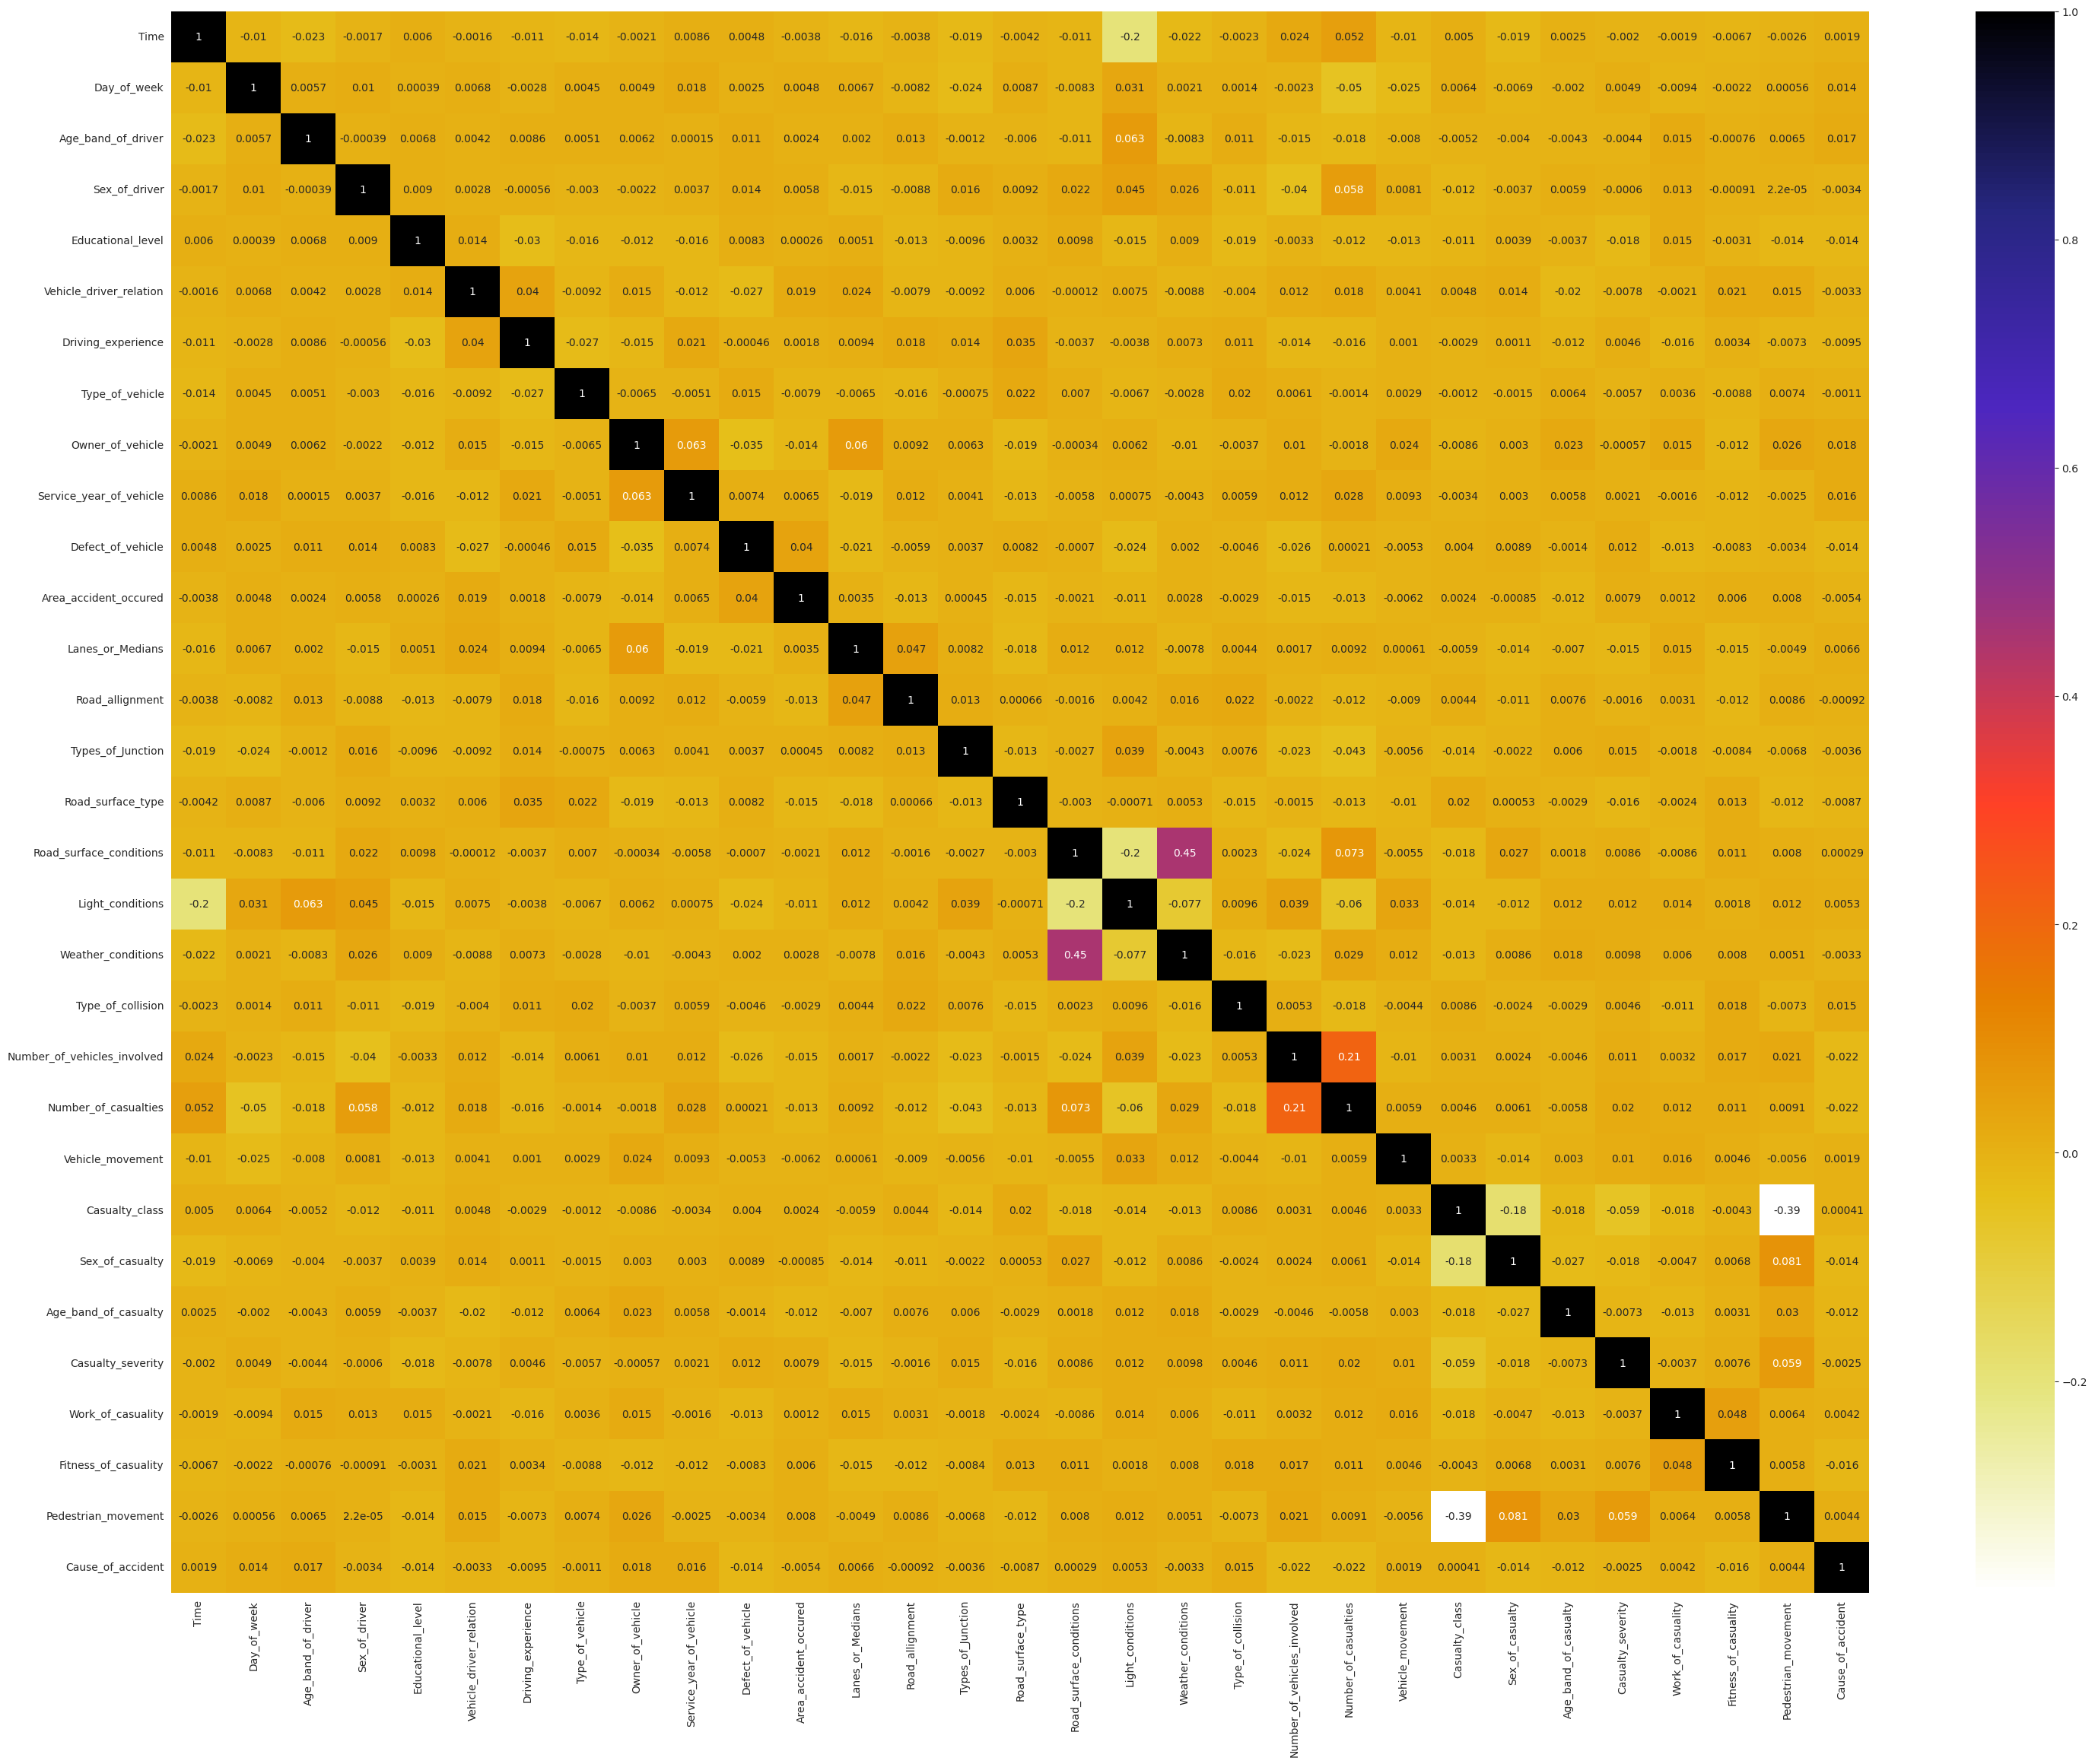

In [61]:
# Heatmap
data_heat = data.drop('Accident_severity', axis = 1)
heatmap(data_heat)

Observation: The features Casualty_class, Sex_of_casualty, Age_band_of_casualty and Casualty_severity are highly correlate

## 9.5  Drop irrelavent Columns

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [62]:
# Drop columns
drop_cols = ['Casualty_class', 'Sex_of_casualty', 'Casualty_severity']
data = data.drop(drop_cols, axis = 1)

## 10. Predictive Modeling


# 10.1 : Separate target

In [63]:
target_col = 'Accident_severity'
y = data[target_col]
X = data.drop(columns=[target_col])

# 10.2 : Train-Test Split

In [64]:

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.2, shuffle = True, random_state = 0)
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test, stratify = y_test, test_size = 0.5, shuffle = True, random_state = 0)


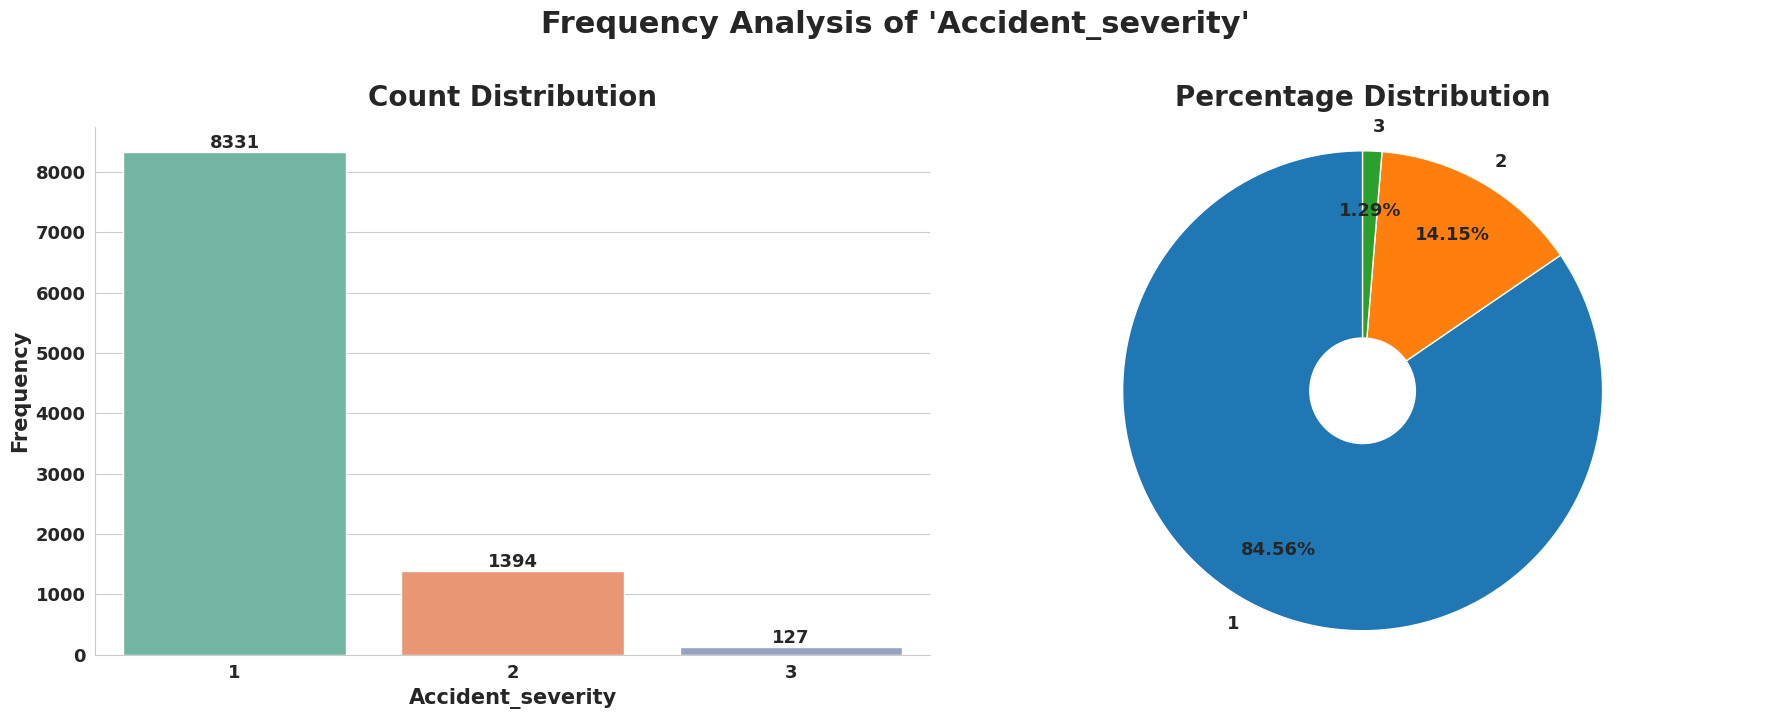

In [65]:
y_train_df = pd.DataFrame(y_train)
plot_count_and_donut(y_train_df, 'Accident_severity')

# 11.1: Model Definition

In [66]:
from sklearn import metrics
def evaluate_model(y_true, y_pred,class_names=None):

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    print("Classification Report:")
    print(classification_report(y_true, y_pred))

     # Default class names
    if class_names is None:
        class_names = ['Slight', 'Serious', 'Fatal']

    # Compute confusion matrix
    cm = metrics.confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

    # Plot
    plt.figure(figsize=(5,4))
    sns.set(font_scale=1)

    sns.heatmap(
        cm_df,
        annot=True,
        fmt='d',
        cmap="Blues",
        annot_kws={"size":12}
    )

    plt.title("Confusion Matrix", fontweight="bold")
    plt.xlabel("Predicted Label", fontweight="bold")
    plt.ylabel("True Label", fontweight="bold")

    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.grid(False)
    plt.tight_layout()
    plt.show()

# 11.1.1: Random Forest

Accuracy: 0.8482
Classification Report:
              precision    recall  f1-score   support

           1       0.85      1.00      0.92      1042
           2       0.71      0.03      0.05       175
           3       0.00      0.00      0.00        15

    accuracy                           0.85      1232
   macro avg       0.52      0.34      0.32      1232
weighted avg       0.82      0.85      0.78      1232



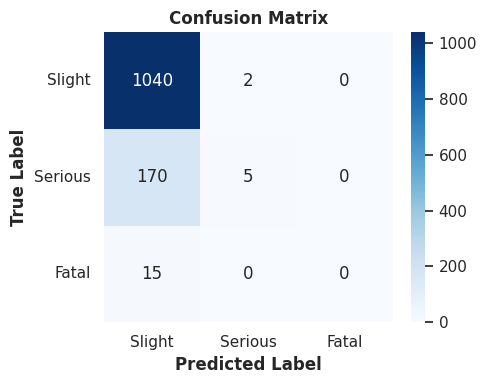

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
random_forest=RandomForestClassifier()
random_forest.fit(X_train,y_train)
y_pred=random_forest.predict(X_test)
evaluate_model(y_test, y_pred)

# 11.1.2: Decision Tree

Accuracy: 0.8409
Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.97      0.91      1042
           2       0.43      0.15      0.22       175
           3       0.50      0.07      0.12        15

    accuracy                           0.84      1232
   macro avg       0.60      0.39      0.42      1232
weighted avg       0.80      0.84      0.80      1232



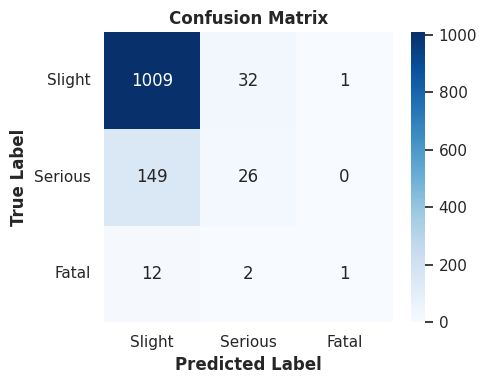

In [68]:
from sklearn.tree import DecisionTreeClassifier
decision_tree=DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42)
decision_tree.fit(X_train,y_train)
y_pred=decision_tree.predict(X_test)
evaluate_model(y_test, y_pred)

## 11.1.3 XGBoost Classifier

The XGBClassifier requires the class column to initiate from , which has been mandatory since version . For this reason, we create separate copies of the class column, initiating from , for the training set, the validation set, and the test set.

In [69]:
y_train_xgb = y_train - 1
y_valid_xgb = y_valid - 1
y_test_xgb = y_test - 1

Accuracy: 0.8547
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      1042
           1       0.61      0.11      0.19       175
           2       1.00      0.13      0.24        15

    accuracy                           0.85      1232
   macro avg       0.82      0.41      0.45      1232
weighted avg       0.83      0.85      0.81      1232



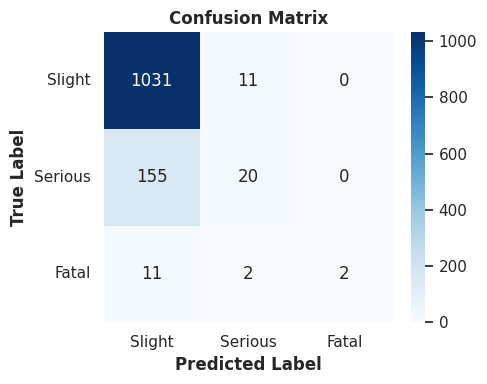

In [70]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state = 0)
xgb.fit(X_train, y_train_xgb)
y_pred = xgb.predict(X_test)
evaluate_model(y_test_xgb, y_pred)

# 11.1.4: ExtraTrees Classifier

Accuracy: 0.8490
Classification Report:
              precision    recall  f1-score   support

           1       0.85      1.00      0.92      1042
           2       1.00      0.02      0.04       175
           3       0.00      0.00      0.00        15

    accuracy                           0.85      1232
   macro avg       0.62      0.34      0.32      1232
weighted avg       0.86      0.85      0.78      1232



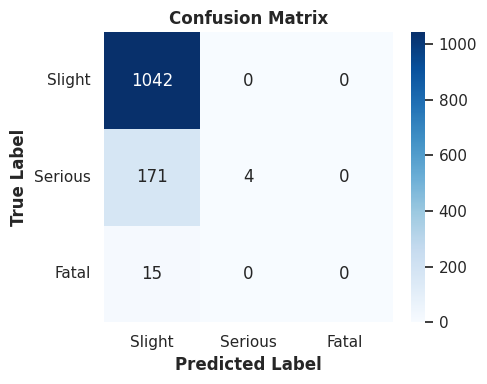

In [71]:
from sklearn.ensemble import ExtraTreesClassifier
extree = ExtraTreesClassifier(random_state = 0)
extree.fit(X_train, y_train)
y_pred = extree.predict(X_test)
evaluate_model(y_test, y_pred)
